<a href="https://colab.research.google.com/github/aditi-govindu/DA6002W_end_term_project/blob/main/DA25G501_ORL_end_term_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Online Reinforcement and Learning end term project

* Name: Aditi Govindu
* Roll no: DA25G501

# Setup from [starter code.ipynb](/content/drive/MyDrive/orl_end_term_project/starter_notebook.ipynb) as it is

In [ ]:
!pip install -r /content/drive/MyDrive/orl_end_term_project/requirements.txt

In [ ]:
# @title Constants & Product Attributes
from copy import deepcopy
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROLL_NUMBER = 'DA25G501'
# Reuse the same seed across the board for posterity.
SEED = 2026

N = 3 # Number of Products
V_max = 1000.0 # Warehouse Capacity
v = np.array([2.0, 3.0, 1.5]) # Product Volumes
c_h = 5.00 # Daily Holding Cost
c_s = np.array([400.0, 500.0, 300.0]) # Stockout Costs
c_o = np.array([80.0, 200.0, 120.0]) # Fixed Ordering Costs
c_d = np.array([200.0, 250.0, 150.0]) # Discarding Costs
L = np.array([3, 2, 1]) # Base Lead Times
mu_d = np.array([30, 25, 35]) # Reference Demand Means
T = 50 # Episode Duration

In [ ]:
# @title Setup from starter code.

# Add the parent directory to sys.path to import industrial_inventory_env.
sys.path.append('/content/drive/MyDrive/orl_end_term_project')

from industrial_inventory_env import (
    IndustrialInventoryEnv,
    generate_student_config,
    public_config_summary,
)

np.set_printoptions(suppress=True)
print('Imports completed.')

student_config = generate_student_config(ROLL_NUMBER)
config_summary = public_config_summary(student_config)

print('Assigned configuration generated successfully.')
for key, value in config_summary.items():
    print(f'{key}: {value}')

Imports completed.
Assigned configuration generated successfully.
project_version: IITM-6002W-RL-Inventory-2026-v1
roll_number: DA25G501
variant_id: V015
config_fingerprint: d018ef2f72ad80b9
demand_multiplier_profile: [1.0, 0.85, 1.15]
initial_inventory_profile: [80, 100, 120]
lead_time_delay_profile: [0.05, 0.1, 0.0]


In [ ]:
# @title Environment setup from starter code.
env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode='random',
    domain_randomization=True,
)

observation, info = env.reset(seed=SEED)

print('Action space:', env.action_space)
print('Observation space:', env.observation_space)
print('Variant:', info['variant_id'])
print('Scenario components:', info['episode_parameters']['scenario_components'])
print('Episode demand multipliers:', info['episode_parameters']['demand_multipliers'])
print('Episode initial inventory:', info['episode_parameters']['initial_inventory'])
print('Episode delay probabilities:', info['episode_parameters']['delay_probabilities'])

Action space: MultiDiscrete([11 11 11])
Observation space: Dict('arrival_pipeline': Box(0, 10000, (3, 4), int32), 'capacity_utilisation': Box(0.0, 1.0, (1,), float32), 'day': Box(0, 50, (1,), int32), 'demand_history': Box(0, 10000, (7, 3), int32), 'inventory': Box(0, 1000, (3,), int32))
Variant: V015
Scenario components: ['seasonal', 'trend']
Episode demand multipliers: [1.05, 0.85, 1.0999999999999999]
Episode initial inventory: [80, 100, 120]
Episode delay probabilities: [0.030000000000000002, 0.1, 0.0]


In [ ]:
# @title Observations and Actions from starter code.
for key, value in observation.items():
    print(f'{key:22s} shape={value.shape}, dtype={value.dtype}')
    print(value)
    print()

order_quantities = [40, 20, 0]
action_indices = env.quantities_to_action_indices(order_quantities)

print('Actual order quantities:', order_quantities)
print('Internal action indices:', action_indices.tolist())
print('Converted back:', env.action_indices_to_quantities(action_indices).tolist())

inventory              shape=(3,), dtype=int32
[ 80 100 120]

arrival_pipeline       shape=(3, 4), dtype=int32
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]

demand_history         shape=(7, 3), dtype=int32
[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]

day                    shape=(1,), dtype=int32
[0]

capacity_utilisation   shape=(1,), dtype=float32
[0.64]

Actual order quantities: [40, 20, 0]
Internal action indices: [4, 2, 0]
Converted back: [40, 20, 0]


In [ ]:
# @title Example of a single interaction.
next_observation, reward, terminated, truncated, step_info = env.step(action_indices)

print('Reward:', reward)
print('Terminated:', terminated)
print('Truncated:', truncated)
print('Demand:', step_info['demand'])
print('Daily costs:', step_info['costs'])
print('Next inventory:', next_observation['inventory'])

Reward: -26.9
Terminated: False
Truncated: False
Demand: [34 16 28]
Daily costs: {'holding': 2410.0, 'stockout': 0.0, 'ordering': 280.0, 'discarding': 0.0, 'daily_total': 2690.0, 'episode_total': 2690.0}
Next inventory: [46 84 92]


In [ ]:
# @title Dummy policy. NOT counted towards 5 policies needed to submit.

def demonstration_policy(observation: dict) -> list[int]:
    'Simple deterministic inventory-position heuristic for demonstration.'
    inventory = np.asarray(observation['inventory'], dtype=float)
    pipeline = np.asarray(observation['arrival_pipeline'], dtype=float)
    inventory_position = inventory + pipeline.sum(axis=1)

    targets = np.asarray([110.0, 100.0, 120.0])
    required = np.maximum(targets - inventory_position, 0.0)
    quantities = np.clip(np.ceil(required / 10.0) * 10.0, 0.0, 100.0)
    return quantities.astype(int).tolist()

# Running a deterministic episode with the code to test dummy policy.
demo_env = IndustrialInventoryEnv(
    student_config,
    scenario_mode='random',
    domain_randomization=True,
)
observation, reset_info = demo_env.reset(seed=SEED)

records = []
while True:
    quantities = demonstration_policy(observation)
    action = demo_env.quantities_to_action_indices(quantities)
    observation, reward, terminated, truncated, info = demo_env.step(action)

    records.append(
        {
            'day': info['day'],
            'reward': reward,
            'daily_cost': info['costs']['daily_total'],
            'episode_cost': info['costs']['episode_total'],
            'inventory_p1': int(observation['inventory'][0]),
            'inventory_p2': int(observation['inventory'][1]),
            'inventory_p3': int(observation['inventory'][2]),
            'order_p1': int(quantities[0]),
            'order_p2': int(quantities[1]),
            'order_p3': int(quantities[2]),
        }
    )

    if terminated or truncated:
        break

one_episode_results = pd.DataFrame(records)
print('Episode days:', len(one_episode_results))
print('Total episode cost:', one_episode_results['daily_cost'].sum())
one_episode_results.head()

Episode days: 50
Total episode cost: 133675.0


,day,reward,daily_cost,episode_cost,inventory_p1,inventory_p2,inventory_p3,order_p1,order_p2,order_p3
0,0,-24.900,2490.0,2490.0,46,84,92,30,0,0
1,1,-19.875,1987.5,4477.5,17,66,57,40,20,30
2,2,-53.450,5345.0,9822.5,0,43,40,30,20,40
3,3,-14.225,1422.5,11245.0,1,44,47,10,20,40
4,4,-15.625,1562.5,12807.5,9,44,55,30,20,40


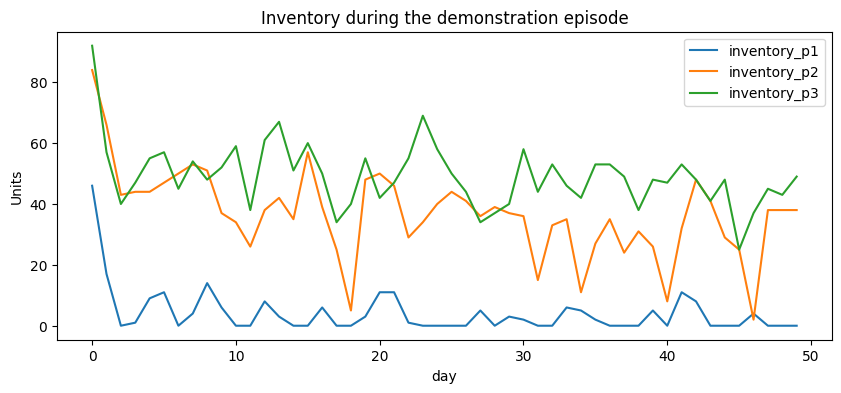

In [ ]:
# @title Plot dummy policy results.
one_episode_results.plot(
    x='day',
    y=['inventory_p1', 'inventory_p2', 'inventory_p3'],
    figsize=(10, 4),
    title='Inventory during the demonstration episode',
)
plt.ylabel('Units')
plt.show()

In [ ]:
# @title Actions and product configs

def preprocess_observation(obs):
    inv = obs['inventory'] / 1000.0  # Normalize inventory
    pipeline = obs['arrival_pipeline'].flatten() / 100.0  # Normalize 3x4 pipeline
    demand_hist = obs['demand_history'].flatten() / 100.0  # Normalize 7x3 demand
    day = np.array([obs['day'] / 50.0])  # Normalize day
    cap = np.array([obs['capacity_utilisation']]) # Already normalized 0-1

    return np.concatenate([inv, pipeline, demand_hist, day, cap], axis=0)

# Translation helpers between RL Discrete/MultiDiscrete indices and policy quantities
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

def action_index_to_quantity(action_indices):
    'Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]'
    return [int(QUANTITIES[idx]) for idx in action_indices]

def quantity_to_action_index(quantities):
    'Convert actual quantities [q1, q2, q3] back to internal indices (0-10)'
    return [int(q // 10) for q in quantities]

# Project by DA25G501

In [ ]:
# @title Local validation loop

def evaluate_policy(
    policy,
    student_config,
    num_episodes: int = 20,
    scenario_modes: list[str] = None,
    domain_randomization: bool = True,
    seeds: list[int] = None,
) -> pd.DataFrame:
    'Evaluates a given policy over multiple episodes and returns performance metrics.'

    if scenario_modes is None:
        scenario_modes = ['random']
    if seeds is None:
        # Generate reproducible seeds if not provided.
        np.random.seed(42)  # Master seed for reproducibility of evaluation.
        seeds = np.random.randint(0, 100000, num_episodes)

    all_episode_costs = []
    all_daily_stockout_events = []
    all_daily_discard_events = []

    for i in range(num_episodes):
        # Cycle through scenario modes if more episodes than modes.
        current_scenario_mode = scenario_modes[i % len(scenario_modes)]
        current_seed = seeds[i]

        # Store same environment as original one assigned to DA25G501.
        env = IndustrialInventoryEnv(
            student_config=student_config,
            scenario_mode=current_scenario_mode,
            domain_randomization=domain_randomization,
        )

        # Cast current_seed to a standard Python integer
        observation, _ = env.reset(seed=SEED)

        episode_daily_costs = []
        # Boolean to store 1 if stockout occurred on that day, 0 otherwise.
        episode_stockout_events = []
        # Boolean array keeps 1 if discarding occurred on that day, 0 otherwise.
        episode_discard_events = []

        terminated = False
        truncated = False
        while not terminated and not truncated:
            quantities = policy(observation)
            action = env.quantities_to_action_indices(quantities)
            observation, reward, terminated, truncated, info = env.step(action)

            episode_daily_costs.append(info['costs']['daily_total'])

            # Check for stockout event: total unfulfilled demand > 0.
            stockout_happened = 1 if info['unfulfilled_demand'].sum() > 0 else 0
            episode_stockout_events.append(stockout_happened)

            # Check for discard event: discarding cost > 0.
            discard_happened = 1 if info['costs']['discarding'] > 0 else 0
            episode_discard_events.append(discard_happened)

        all_episode_costs.append(sum(episode_daily_costs))
        all_daily_stockout_events.extend(episode_stockout_events)
        all_daily_discard_events.extend(episode_discard_events)

    # Calculate metrics
    M = num_episodes
    # Run loop for 50 days.
    total_days = T * M

    mean_episode_cost = np.mean(all_episode_costs)
    cost_std_dev = np.std(all_episode_costs)
    stockout_frequency = np.sum(all_daily_stockout_events) / total_days
    discard_event_rate = np.sum(all_daily_discard_events) / total_days

    results = pd.DataFrame({
        'Mean Episode Cost': [mean_episode_cost],
        'Cost Standard Deviation': [cost_std_dev],
        'Stockout Frequency': [stockout_frequency],
        'Capacity Discard Event Rate': [discard_event_rate],
    })

    return results


In [ ]:
def calculate_costs_and_reward(
    inventory: np.ndarray, # I_{i,t} on-hand inventory after serving demand
    inventory_available: np.ndarray, # I_{i,t}^available on-hand stock prior to fulfillment
    demand: np.ndarray, # D_{i,t} realized demand
    orders: np.ndarray, # q_{i,t} ordered quantities
    discarded_units: np.ndarray, # K_{i,t} allocated discard quantities
) -> dict:
    """Calculates various cost components and the base reward based on environment state and actions.

    Args:
        inventory: Current on-hand inventory per product after serving demand.
        inventory_available: On-hand stock prior to demand fulfillment.
        demand: Realized demand for each product.
        orders: Ordered quantities for each product.
        discarded_units: Quantities of each product discarded due to capacity limits.

    Returns:
        A dictionary containing holding, stockout, ordering, discarding, daily total costs, and the base reward.
    """

    # 1. Holding Cost (C_h_t)
    V_t = np.sum(v * inventory)
    C_h_t = V_t * c_h

    # 2. Stockout Cost (C_s_t)
    C_s_t = np.sum(c_s * np.maximum(0, demand - inventory_available))

    # 3. Ordering Cost (C_o_t)
    # np.sum(orders > 0) counts the number of products for which orders > 0
    C_o_t = np.sum(c_o * (orders > 0).astype(int))

    # 4. Discarding Cost (C_d_t)
    C_d_t = np.sum(c_d * discarded_units)

    # 5. Total Daily Cost & Official Base Reward
    Daily_Cost_t = C_h_t + C_s_t + C_o_t + C_d_t
    R_base_t = -Daily_Cost_t / 100.0

    return {
        "holding_cost": C_h_t,
        "stockout_cost": C_s_t,
        "ordering_cost": C_o_t,
        "discarding_cost": C_d_t,
        "daily_total_cost": Daily_Cost_t,
        "base_reward": R_base_t,
    }

In [ ]:
### 3.1 Continuous State Normalization (Deep RL Input Layer)
def continuous_state_normalization(obs: dict) -> np.ndarray:
    """Normalizes and flattens the raw observation dictionary into a continuous vector.

    Args:
        obs: The raw observation dictionary from the environment.

    Returns:
        A numpy array representing the normalized continuous state vector.
    """
    # I_t / 500.0
    inventory_norm = obs["inventory"].astype(float) / 500.0
    # vec(P_t) / 200.0
    pipeline_norm = obs["arrival_pipeline"].flatten().astype(float) / 200.0
    # vec(H_t) / 100.0
    demand_history_norm = obs["demand_history"].flatten().astype(float) / 100.0
    # t / 50.0
    day_norm = obs["day"].astype(float) / 50.0 # Corrected: Removed extra np.array([]) wrapper
    # U_t (already normalized)
    capacity_utilisation_norm = obs["capacity_utilisation"].astype(float) # Ensure float type

    return np.concatenate([
        inventory_norm,
        pipeline_norm,
        demand_history_norm,
        day_norm,
        capacity_utilisation_norm
    ], axis=0)

### 3.2 Discrete State Aggregation (Tabular RL Input Layer)
def discrete_state_aggregation(obs: dict) -> int:
    """Aggregates continuous state variables into a single discrete state index.

    Args:
        obs: The raw observation dictionary from the environment.

    Returns:
        An integer representing the discrete state index.
    """
    # Inventory Bins (per product): Low ([0, 30)), Medium ([30, 80)), High (>= 80).
    # (3^3 = 27 states)
    inventory_bins = []
    for i in range(N):
        if obs["inventory"][i] < 30:
            inventory_bins.append(0) # Low
        elif obs["inventory"][i] < 80:
            inventory_bins.append(1) # Medium
        else:
            inventory_bins.append(2) # High
    # Convert base-3 representation to a single integer
    inventory_state = inventory_bins[0] * 9 + inventory_bins[1] * 3 + inventory_bins[2] * 1

    # Total Pipeline Sum Bins (per product): Low ([0, 30)), High (>= 30).
    # (2^3 = 8 states)
    pipeline_bins = []
    for i in range(N):
        total_pipeline_sum = obs["arrival_pipeline"][i].sum()
        if total_pipeline_sum < 30:
            pipeline_bins.append(0) # Low
        else:
            pipeline_bins.append(1) # High
    # Convert base-2 representation to a single integer
    pipeline_state = pipeline_bins[0] * 4 + pipeline_bins[1] * 2 + pipeline_bins[2] * 1

    # Episode Phase: Early (t <= 15), Mid (15 < t <= 35), Late (t > 35).
    # (3 states)
    day = obs["day"][0] # day is a np.array([day_value])
    if day <= 15:
        day_state = 0 # Early
    elif day <= 35:
        day_state = 1 # Mid
    else:
        day_state = 2 # Late

    # Total Tabular State Space Size: 27 * 8 * 3 = 648 state indices.
    # Combined state: inv_state * (8 * 3) + pipe_state * 3 + day_state
    # This mapping ensures unique state indices for each combination of bins.
    discrete_state = inventory_state * (8 * 3) + pipeline_state * 3 + day_state

    return discrete_state

### Tabular Q-Learning Implementation

Tabular Q-Learning is a model-free reinforcement learning algorithm used to learn the value of state-action pairs. It uses a Q-table to store and update Q-values. The agent learns an optimal policy by interacting with the environment and updating its Q-values based on observed rewards and future maximum Q-values.

**Update Rule:**
$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_t + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \right]$$

**Inference Policy:** $A^* = \arg\max_{a} Q(S, a)$

In [ ]:
# Define Q-table dimensions and initialize
NUM_DISCRETE_STATES = 27 * 8 * 3  # From discrete_state_aggregation (Inventory * Pipeline * DayPhase)
NUM_PRODUCTS = N  # N is defined as 3 previously
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES) # 11 (0 to 100 in steps of 10)
NUM_TOTAL_ACTIONS = NUM_CHOICES_PER_PRODUCT ** NUM_PRODUCTS # 11^3 = 1331

# Initialize Q-table with zeros
q_table = np.zeros((NUM_DISCRETE_STATES, NUM_TOTAL_ACTIONS))

# Q-Learning Hyperparameters
ALPHA = 0.1     # Learning rate
GAMMA = 0.99    # Discount factor
EPSILON = 1.0   # Exploration-exploitation trade-off (will decay)
EPSILON_DECAY = 0.995 # Epsilon decay rate
MIN_EPSILON = 0.01

print(f"Q-table initialized with dimensions: {q_table.shape}")

Q-table initialized with dimensions: (648, 1331)


In [ ]:
# Helper functions for action mapping
def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    """Converts a single integer action index to a MultiDiscrete action tuple."""
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def map_multi_discrete_to_action_index(multi_discrete_action: list[int]) -> int:
    """Converts a MultiDiscrete action tuple to a single integer action index."""
    action_idx = 0
    for i, val in enumerate(multi_discrete_action):
        action_idx += val * (NUM_CHOICES_PER_PRODUCT ** (NUM_PRODUCTS - 1 - i))
    return action_idx

# Test mapping functions
# Example: Action [40, 20, 0] -> MultiDiscrete [4, 2, 0]
# Corresponding action index:
# 4 * (11^2) + 2 * (11^1) + 0 * (11^0) = 4 * 121 + 2 * 11 + 0 = 484 + 22 = 506

test_multi_discrete = [4, 2, 0]
test_single_index = map_multi_discrete_to_action_index(test_multi_discrete)
print(f"MultiDiscrete action {test_multi_discrete} maps to single index: {test_single_index}")

converted_back = map_action_index_to_multi_discrete(test_single_index)
print(f"Single index {test_single_index} maps back to MultiDiscrete action: {converted_back}")
assert converted_back == test_multi_discrete


MultiDiscrete action [4, 2, 0] maps to single index: 506
Single index 506 maps back to MultiDiscrete action: [4, 2, 0]


In [ ]:
def train_q_learning(
    env: IndustrialInventoryEnv,
    q_table: np.ndarray,
    num_episodes: int,
    alpha: float,
    gamma: float,
    epsilon: float,
    epsilon_decay: float,
    min_epsilon: float,
) -> tuple[np.ndarray, list[float]]:
    """Trains a Q-Learning agent on the Industrial Inventory environment."""
    episode_costs = []
    current_epsilon = epsilon

    for episode in range(num_episodes):
        observation, _ = env.reset(seed=SEED) # Use the global SEED for each episode
        state = discrete_state_aggregation(observation)

        terminated = False
        truncated = False
        episode_total_cost = 0.0

        while not terminated and not truncated:
            # Epsilon-greedy action selection
            if np.random.rand() < current_epsilon:
                # Explore: choose a random action index
                action_idx = np.random.randint(0, NUM_TOTAL_ACTIONS)
            else:
                # Exploit: choose action with max Q-value
                action_idx = np.argmax(q_table[state, :])

            # Convert single action index to environment's MultiDiscrete indices
            multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
            # Convert MultiDiscrete indices to actual quantities
            quantities = action_index_to_quantity(multi_discrete_action)
            # Convert quantities to environment's internal action indices for `env.step`
            env_action_indices = env.quantities_to_action_indices(quantities)

            # Take action and observe next state and reward
            next_observation, reward, terminated, truncated, info = env.step(env_action_indices)
            next_state = discrete_state_aggregation(next_observation)
            episode_total_cost += info["costs"]["daily_total"]

            # Q-Learning Update Rule
            # Q(S_t, A_t) <- Q(S_t, A_t) + alpha * [R_t + gamma * max_a Q(S_{t+1}, a) - Q(S_t, A_t)]
            old_q_value = q_table[state, action_idx]
            if terminated or truncated:
                # No future state if episode ends
                max_future_q = 0
            else:
                max_future_q = np.max(q_table[next_state, :])

            new_q_value = old_q_value + alpha * (reward + gamma * max_future_q - old_q_value)
            q_table[state, action_idx] = new_q_value

            state = next_state

        episode_costs.append(episode_total_cost)

        # Decay epsilon
        current_epsilon = max(min_epsilon, current_epsilon * epsilon_decay)

        if (episode + 1) % 100 == 0 or episode == num_episodes - 1:
            print(f"Episode {episode + 1}/{num_episodes}, Total Cost: {episode_total_cost:.2f}, Epsilon: {current_epsilon:.4f}")

    return q_table, episode_costs

In [ ]:
def q_learning_inference_policy(observation: dict, q_table: np.ndarray) -> list[int]:
    """Inference policy for Tabular Q-Learning, taking observation and returning quantities."""
    # Get discrete state from observation
    state = discrete_state_aggregation(observation)

    # Choose action with the highest Q-value (exploitation only)
    action_idx = np.argmax(q_table[state, :])

    # Convert single action index to MultiDiscrete action tuple
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)

    # Convert MultiDiscrete indices to actual quantities
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

Starting Q-Learning training...
Episode 100/2000, Total Cost: 583647.50, Epsilon: 0.6058
Episode 200/2000, Total Cost: 978865.00, Epsilon: 0.3670
Episode 300/2000, Total Cost: 855847.50, Epsilon: 0.2223
Episode 400/2000, Total Cost: 944757.50, Epsilon: 0.1347
Episode 500/2000, Total Cost: 952380.00, Epsilon: 0.0816
Episode 600/2000, Total Cost: 930345.00, Epsilon: 0.0494
Episode 700/2000, Total Cost: 1241122.50, Epsilon: 0.0299
Episode 800/2000, Total Cost: 944960.00, Epsilon: 0.0181
Episode 900/2000, Total Cost: 899107.50, Epsilon: 0.0110
Episode 1000/2000, Total Cost: 1114400.00, Epsilon: 0.0100
Episode 1100/2000, Total Cost: 868805.00, Epsilon: 0.0100
Episode 1200/2000, Total Cost: 1004787.50, Epsilon: 0.0100
Episode 1300/2000, Total Cost: 1043342.50, Epsilon: 0.0100
Episode 1400/2000, Total Cost: 724562.50, Epsilon: 0.0100
Episode 1500/2000, Total Cost: 1342130.00, Epsilon: 0.0100
Episode 1600/2000, Total Cost: 877992.50, Epsilon: 0.0100
Episode 1700/2000, Total Cost: 763457.50, Ep

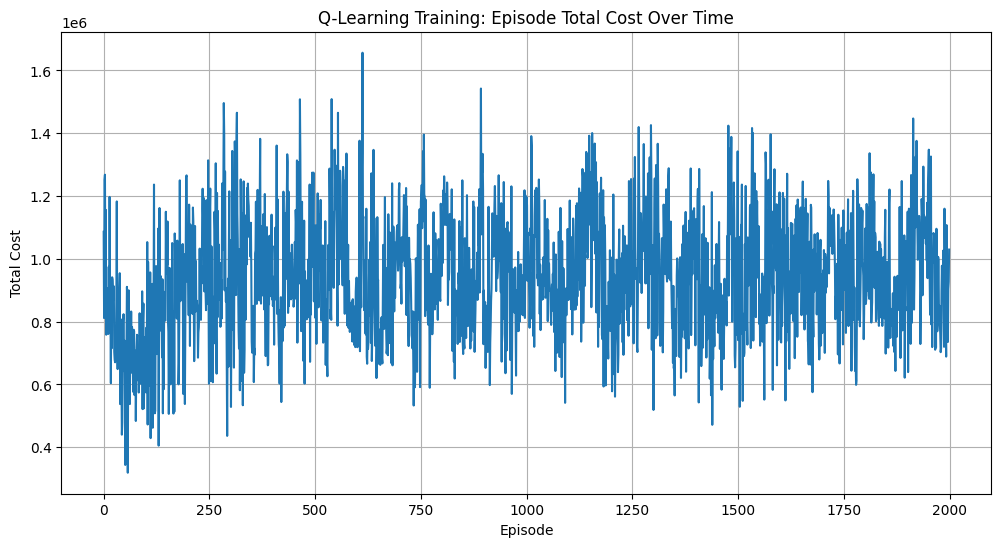


Evaluating trained Q-Learning policy...
Q-Learning Evaluation Results:


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,1078176.25,79723.75,0.77,0.58


In [ ]:
# Train the Q-Learning agent
print("Starting Q-Learning training...")
# Create a fresh environment instance for training
training_env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

# Initialize Q-table for training (can reuse the one defined globally or create a new one)
trained_q_table, training_episode_costs = train_q_learning(
    env=training_env,
    q_table=np.zeros((NUM_DISCRETE_STATES, NUM_TOTAL_ACTIONS)), # Start with a fresh Q-table
    num_episodes=2000, # Number of training episodes
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY,
    min_epsilon=MIN_EPSILON,
)

print("Q-Learning training finished.")

# Plot learning curve
plt.figure(figsize=(12, 6))
plt.plot(training_episode_costs)
plt.title("Q-Learning Training: Episode Total Cost Over Time")
plt.xlabel("Episode")
plt.ylabel("Total Cost")
plt.grid(True)
plt.show()

# Evaluate the trained policy
print("\nEvaluating trained Q-Learning policy...")
# Wrap the policy to pass the trained_q_table
def q_learning_policy_for_eval(observation: dict) -> list[int]:
    return q_learning_inference_policy(observation, trained_q_table)

# Evaluate the policy using the evaluation function
q_learning_results = evaluate_policy(
    policy=q_learning_policy_for_eval,
    student_config=student_config,
    num_episodes=20, # Use more episodes for robust evaluation
    scenario_modes=["random", "seasonal"], # Corrected 'constant' to 'seasonal'
    domain_randomization=True,
)

print("Q-Learning Evaluation Results:")
display(q_learning_results)

# You can store trained_q_table if needed for later use or saving the model
# np.save('q_table_trained.npy', trained_q_table)


In [ ]:
# @title Saving Q-learning model
model_path = 'q_table_trained.npy'
np.save(model_path, trained_q_table)
print(f"Trained Tabular Q-learning model saved to {model_path}")

Trained Tabular Q-learning model saved to q_table_trained.npy


In [ ]:
# @title Inference using saved Tabular Q-learning model
import numpy as np
from pathlib import Path

N = 3 # Number of Products
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
NUM_PRODUCTS = N
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES) # 11 (0 to 100 in steps of 10)
NUM_TOTAL_ACTIONS = NUM_CHOICES_PER_PRODUCT ** NUM_PRODUCTS # 11^3 = 1331
NUM_DISCRETE_STATES = 27 * 8 * 3  # From discrete_state_aggregation (Inventory * Pipeline * DayPhase)

# --- Helper Functions (copied from notebook for self-containment) ---
def discrete_state_aggregation(obs: dict) -> int:
    """Aggregates continuous state variables into a single discrete state index."""
    # Inventory Bins (per product): Low ([0, 30)), Medium ([30, 80)), High (>= 80).
    inventory_bins = []
    for i in range(N):
        if obs["inventory"][i] < 30:
            inventory_bins.append(0) # Low
        elif obs["inventory"][i] < 80:
            inventory_bins.append(1) # Medium
        else:
            inventory_bins.append(2) # High
    inventory_state = inventory_bins[0] * 9 + inventory_bins[1] * 3 + inventory_bins[2] * 1

    # Total Pipeline Sum Bins (per product): Low ([0, 30)), High (>= 30).
    pipeline_bins = []
    for i in range(N):
        total_pipeline_sum = obs["arrival_pipeline"][i].sum()
        if total_pipeline_sum < 30:
            pipeline_bins.append(0) # Low
        else:
            pipeline_bins.append(1) # High
    pipeline_state = pipeline_bins[0] * 4 + pipeline_bins[1] * 2 + pipeline_bins[2] * 1

    # Episode Phase: Early (t <= 15), Mid (15 < t <= 35), Late (t > 35).
    day = obs["day"][0]
    if day <= 15:
        day_state = 0 # Early
    elif day <= 35:
        day_state = 1 # Mid
    else:
        day_state = 2 # Late

    discrete_state = inventory_state * (8 * 3) + pipeline_state * 3 + day_state
    return discrete_state

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    """Converts a single integer action index to a MultiDiscrete action tuple."""
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    """Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]"""
    return [int(QUANTITIES[idx]) for idx in action_indices]

# --- Global Q-table Instance and Loading for policy.py ---
# This Q-table will be loaded once when the policy.py module is imported.
initial_q_table = np.zeros((NUM_DISCRETE_STATES, NUM_TOTAL_ACTIONS))

# Define the path to your saved model file.
# In a submission, 'q_table_trained.npy' should be in the same directory as 'policy.py'
model_path = Path('./q_table_trained.npy') # Assuming model is saved in the same directory

if model_path.exists():
    try:
        q_table = np.load(model_path)
        print(f"Q-table loaded successfully from {model_path}")
    except Exception as e:
        print(f"Error loading Q-table from {model_path}: {e}")
        print("Q-table initialized with zeros instead.")
        q_table = initial_q_table
else:
    print(f"Warning: Model file not found at {model_path}. Q-table initialized with zeros.")
    print("Please ensure your trained 'q_table_trained.npy' is saved in the correct location.")
    q_table = initial_q_table


# --- Main Policy Function for Submission ---
def run_policy(observation: dict) -> list[int]:
    """Return order quantities for Products 1, 2 and 3 using the trained Tabular Q-Learning policy."""

    # Get discrete state from observation
    state = discrete_state_aggregation(observation)

    # Choose action with the highest Q-value (exploitation only)
    action_idx = np.argmax(q_table[state, :])

    # Convert single action index to MultiDiscrete action tuple
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)

    # Convert MultiDiscrete indices to actual quantities
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# --- Example Usage (This block is for testing and would NOT be in the final policy.py submission) ---
# You can uncomment and run this locally to test your policy.
# When submitted, this __name__ == '__main__' block will not be executed.
if __name__ == '__main__':
    print("\n--- Testing run_policy function ---")
    dummy_observation = {
        'inventory': np.array([50, 60, 70], dtype=np.int32),
        'arrival_pipeline': np.zeros((3, 4), dtype=np.int32),
        'demand_history': np.zeros((7, 3), dtype=np.int32),
        'day': np.array([10], dtype=np.int32),
        'capacity_utilisation': np.array([0.5], dtype=np.float32)
    }
    recommended_quantities = run_policy(dummy_observation)
    print(f"Recommended quantities for dummy observation: {recommended_quantities}")

Q-table loaded successfully from q_table_trained.npy

--- Testing run_policy function ---
Recommended quantities for dummy observation: [0, 0, 20]


## Tabular SARSA
- **Update Rule:**
  $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_t + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) \right]$$
- **Inference Policy:** $A^* = \arg\max_{a} Q(S, a)$

Starting SARSA training...
Episode 100/2000, Total Cost: 523907.50, Epsilon: 0.6058
Episode 200/2000, Total Cost: 1057365.00, Epsilon: 0.3670
Episode 300/2000, Total Cost: 646662.50, Epsilon: 0.2223
Episode 400/2000, Total Cost: 786492.50, Epsilon: 0.1347
Episode 500/2000, Total Cost: 1043812.50, Epsilon: 0.0816
Episode 600/2000, Total Cost: 1043417.50, Epsilon: 0.0494
Episode 700/2000, Total Cost: 784592.50, Epsilon: 0.0299
Episode 800/2000, Total Cost: 890690.00, Epsilon: 0.0181
Episode 900/2000, Total Cost: 1327812.50, Epsilon: 0.0110
Episode 1000/2000, Total Cost: 1154620.00, Epsilon: 0.0100
Episode 1100/2000, Total Cost: 887940.00, Epsilon: 0.0100
Episode 1200/2000, Total Cost: 974320.00, Epsilon: 0.0100
Episode 1300/2000, Total Cost: 888715.00, Epsilon: 0.0100
Episode 1400/2000, Total Cost: 1072885.00, Epsilon: 0.0100
Episode 1500/2000, Total Cost: 1026925.00, Epsilon: 0.0100
Episode 1600/2000, Total Cost: 1026092.50, Epsilon: 0.0100
Episode 1700/2000, Total Cost: 952755.00, Epsi

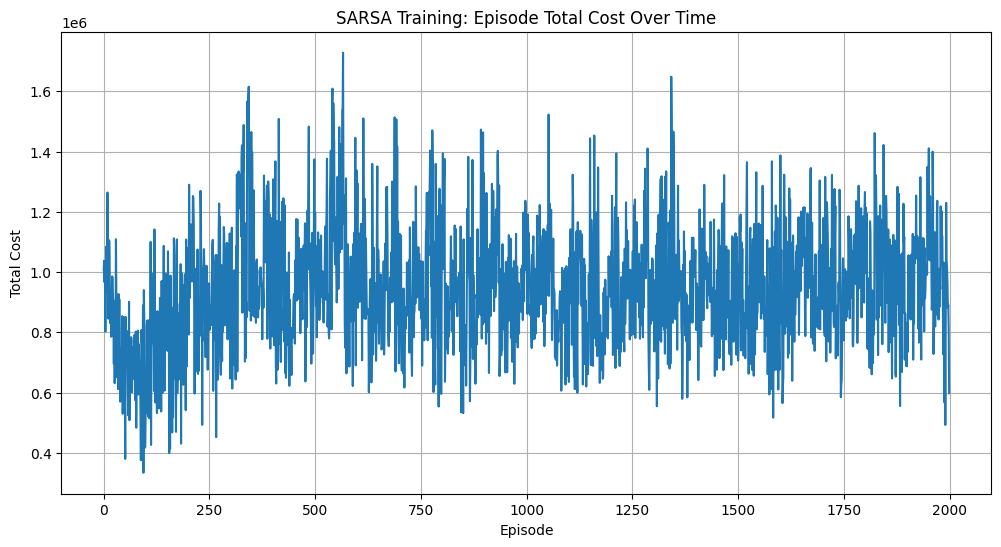


Evaluating trained SARSA policy...
SARSA Evaluation Results:


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,857895.0,38717.5,0.37,0.73


In [ ]:
### Tabular SARSA Implementation

def train_sarsa(
    env: IndustrialInventoryEnv,
    q_table: np.ndarray,
    num_episodes: int,
    alpha: float,
    gamma: float,
    epsilon: float,
    epsilon_decay: float,
    min_epsilon: float,
) -> tuple[np.ndarray, list[float]]:
    """Trains a SARSA agent on the Industrial Inventory environment."""
    episode_costs = []
    current_epsilon = epsilon

    for episode in range(num_episodes):
        observation, _ = env.reset(seed=SEED) # Use the global SEED for each episode
        state = discrete_state_aggregation(observation)

        # Choose initial action A_t using epsilon-greedy policy
        if np.random.rand() < current_epsilon:
            action_idx = np.random.randint(0, NUM_TOTAL_ACTIONS)
        else:
            action_idx = np.argmax(q_table[state, :])

        terminated = False
        truncated = False
        episode_total_cost = 0.0

        while not terminated and not truncated:
            # Convert single action index to environment's MultiDiscrete indices
            multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
            # Convert MultiDiscrete indices to actual quantities
            quantities = action_index_to_quantity(multi_discrete_action)
            # Convert quantities to environment's internal action indices for `env.step`
            env_action_indices = env.quantities_to_action_indices(quantities)

            # Take action A_t and observe next state S_{t+1} and reward R_t
            next_observation, reward, terminated, truncated, info = env.step(env_action_indices)
            next_state = discrete_state_aggregation(next_observation)
            episode_total_cost += info["costs"]["daily_total"]

            # Choose next action A_{t+1} using epsilon-greedy policy from S_{t+1}
            if terminated or truncated:
                # If episode ends, no next action, so Q(S_{t+1}, A_{t+1}) is 0
                next_action_idx = None # Will not be used
                q_s_prime_a_prime = 0
            else:
                if np.random.rand() < current_epsilon:
                    next_action_idx = np.random.randint(0, NUM_TOTAL_ACTIONS)
                else:
                    next_action_idx = np.argmax(q_table[next_state, :])
                q_s_prime_a_prime = q_table[next_state, next_action_idx]

            # SARSA Update Rule
            # Q(S_t, A_t) <- Q(S_t, A_t) + alpha * [R_t + gamma * Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)]
            old_q_value = q_table[state, action_idx]
            new_q_value = old_q_value + alpha * (reward + gamma * q_s_prime_a_prime - old_q_value)
            q_table[state, action_idx] = new_q_value

            # Move to next state and action
            state = next_state
            action_idx = next_action_idx # A_{t+1} becomes A_t for the next iteration

        episode_costs.append(episode_total_cost)

        # Decay epsilon
        current_epsilon = max(min_epsilon, current_epsilon * epsilon_decay)

        if (episode + 1) % 100 == 0 or episode == num_episodes - 1:
            print(f"Episode {episode + 1}/{num_episodes}, Total Cost: {episode_total_cost:.2f}, Epsilon: {current_epsilon:.4f}")

    return q_table, episode_costs

# The inference policy for SARSA is the same as Q-Learning (greedy choice)
def sarsa_inference_policy(observation: dict, q_table: np.ndarray) -> list[int]:
    """Inference policy for Tabular SARSA, taking observation and returning quantities."""
    # Get discrete state from observation
    state = discrete_state_aggregation(observation)

    # Choose action with the highest Q-value (exploitation only)
    action_idx = np.argmax(q_table[state, :])

    # Convert single action index to MultiDiscrete action tuple
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)

    # Convert MultiDiscrete indices to actual quantities
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# Train the SARSA agent
print("Starting SARSA training...")
# Create a fresh environment instance for training
training_env_sarsa = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

# Initialize Q-table for training
trained_sarsa_q_table, sarsa_training_episode_costs = train_sarsa(
    env=training_env_sarsa,
    q_table=np.zeros((NUM_DISCRETE_STATES, NUM_TOTAL_ACTIONS)), # Start with a fresh Q-table
    num_episodes=2000, # Number of training episodes
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY,
    min_epsilon=MIN_EPSILON,
)

print("SARSA training finished.")

# Plot learning curve
plt.figure(figsize=(12, 6))
plt.plot(sarsa_training_episode_costs)
plt.title("SARSA Training: Episode Total Cost Over Time")
plt.xlabel("Episode")
plt.ylabel("Total Cost")
plt.grid(True)
plt.show()

# Evaluate the trained SARSA policy
print("\nEvaluating trained SARSA policy...")
# Wrap the policy to pass the trained_sarsa_q_table
def sarsa_policy_for_eval(observation: dict) -> list[int]:
    return sarsa_inference_policy(observation, trained_sarsa_q_table)

# Evaluate the policy using the evaluation function
sarsa_results = evaluate_policy(
    policy=sarsa_policy_for_eval,
    student_config=student_config,
    num_episodes=20, # Use more episodes for robust evaluation
    scenario_modes=["random", "seasonal"],
    domain_randomization=True,
)

print("SARSA Evaluation Results:")
display(sarsa_results)


In [ ]:
# @title Saving Tabular SARSA model
sarsa_path = 'sarsa_table_trained.npy'
model_save_path = np.save(sarsa_path, trained_sarsa_q_table)
print(f"Trained Tabular SARSA model saved to {sarsa_path}")

Trained Tabular SARSA model saved to sarsa_table_trained.npy


In [ ]:
# @title Inference using saved Tabular SARSA model
import numpy as np
from pathlib import Path

# --- Constants (must match values used during training) ---
# These values are derived from your notebook's global constants and environment setup.
# Ensure these match the definitions in your training notebook.
N = 3 # Number of Products
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
NUM_PRODUCTS = N
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES) # 11 (0 to 100 in steps of 10)
NUM_TOTAL_ACTIONS = NUM_CHOICES_PER_PRODUCT ** NUM_PRODUCTS # 11^3 = 1331
NUM_DISCRETE_STATES = 27 * 8 * 3  # From discrete_state_aggregation (Inventory * Pipeline * DayPhase)

# --- Helper Functions (copied from notebook for self-containment) ---
def discrete_state_aggregation(obs: dict) -> int:
    """Aggregates continuous state variables into a single discrete state index."""
    # Inventory Bins (per product): Low ([0, 30)), Medium ([30, 80)), High (>= 80).
    inventory_bins = []
    for i in range(N):
        if obs["inventory"][i] < 30:
            inventory_bins.append(0) # Low
        elif obs["inventory"][i] < 80:
            inventory_bins.append(1) # Medium
        else:
            inventory_bins.append(2) # High
    inventory_state = inventory_bins[0] * 9 + inventory_bins[1] * 3 + inventory_bins[2] * 1

    # Total Pipeline Sum Bins (per product): Low ([0, 30)), High (>= 30).
    pipeline_bins = []
    for i in range(N):
        total_pipeline_sum = obs["arrival_pipeline"][i].sum()
        if total_pipeline_sum < 30:
            pipeline_bins.append(0) # Low
        else:
            pipeline_bins.append(1) # High
    pipeline_state = pipeline_bins[0] * 4 + pipeline_bins[1] * 2 + pipeline_bins[2] * 1

    # Episode Phase: Early (t <= 15), Mid (15 < t <= 35), Late (t > 35).
    day = obs["day"][0]
    if day <= 15:
        day_state = 0 # Early
    elif day <= 35:
        day_state = 1 # Mid
    else:
        day_state = 2 # Late

    discrete_state = inventory_state * (8 * 3) + pipeline_state * 3 + day_state
    return discrete_state

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    """Converts a single integer action index to a MultiDiscrete action tuple."""
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    """Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]"""
    return [int(QUANTITIES[idx]) for idx in action_indices]

# --- Global Q-table Instance and Loading for policy.py ---
# This Q-table will be loaded once when the policy.py module is imported.
initial_sarsa_q_table = np.zeros((NUM_DISCRETE_STATES, NUM_TOTAL_ACTIONS))

# Define the path to your saved model file.
# In a submission, 'sarsa_table_trained.npy' should be in the same directory as 'policy.py'
model_path = Path('./sarsa_table_trained.npy') # Assuming model is saved in the same directory

if model_path.exists():
    try:
        sarsa_q_table = np.load(model_path)
        print(f"SARSA Q-table loaded successfully from {model_path}")
    except Exception as e:
        print(f"Error loading SARSA Q-table from {model_path}: {e}")
        print("SARSA Q-table initialized with zeros instead.")
        sarsa_q_table = initial_sarsa_q_table
else:
    print(f"Warning: Model file not found at {model_path}. SARSA Q-table initialized with zeros.")
    print("Please ensure your trained 'sarsa_table_trained.npy' is saved in the correct location.")
    sarsa_q_table = initial_sarsa_q_table


# --- Main Policy Function for Submission ---
def run_policy(observation: dict) -> list[int]:
    """Return order quantities for Products 1, 2 and 3 using the trained Tabular SARSA policy."""

    # Get discrete state from observation
    state = discrete_state_aggregation(observation)

    # Choose action with the highest Q-value (exploitation only)
    action_idx = np.argmax(sarsa_q_table[state, :])

    # Convert single action index to MultiDiscrete action tuple
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)

    # Convert MultiDiscrete indices to actual quantities
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# --- Example Usage (This block is for testing and would NOT be in the final policy.py submission) ---
# You can uncomment and run this locally to test your policy.
# When submitted, this __name__ == '__main__' block will not be executed.
if __name__ == '__main__':
    print("\n--- Testing run_policy function for SARSA ---")
    dummy_observation = {
        'inventory': np.array([50, 60, 70], dtype=np.int32),
        'arrival_pipeline': np.zeros((3, 4), dtype=np.int32),
        'demand_history': np.zeros((7, 3), dtype=np.int32),
        'day': np.array([10], dtype=np.int32),
        'capacity_utilisation': np.array([0.5], dtype=np.float32)
    }
    recommended_quantities = run_policy(dummy_observation)
    print(f"Recommended quantities for dummy observation: {recommended_quantities}")

SARSA Q-table loaded successfully from sarsa_table_trained.npy

--- Testing run_policy function for SARSA ---
Recommended quantities for dummy observation: [0, 0, 10]


## Deep Q-Network (DQN)

**Loss Function:** $$L(\theta) = \mathbb{E}_{(s, a, r, s') \sim \mathcal{D}} \left[ \left( r + \gamma \max_{a'} Q(s', a'; \theta^-) - Q(s, a; \theta) \right)^2 \right]$$ where $\theta^-$ denotes parameters of the target network updated every $C$ steps.

Starting DQN training...
Episode 100/2000, Total Cost: 1100020.00, Epsilon: 0.6058
Episode 200/2000, Total Cost: 892102.50, Epsilon: 0.3670
Episode 300/2000, Total Cost: 864720.00, Epsilon: 0.2223
Episode 400/2000, Total Cost: 265932.50, Epsilon: 0.1347
Episode 500/2000, Total Cost: 227897.50, Epsilon: 0.0816
Episode 600/2000, Total Cost: 259360.00, Epsilon: 0.0494
Episode 700/2000, Total Cost: 148450.00, Epsilon: 0.0299
Episode 800/2000, Total Cost: 145960.00, Epsilon: 0.0181
Episode 900/2000, Total Cost: 137815.00, Epsilon: 0.0110
Episode 1000/2000, Total Cost: 144505.00, Epsilon: 0.0100
Episode 1100/2000, Total Cost: 117865.00, Epsilon: 0.0100
Episode 1200/2000, Total Cost: 110682.50, Epsilon: 0.0100
Episode 1300/2000, Total Cost: 109800.00, Epsilon: 0.0100
Episode 1400/2000, Total Cost: 112280.00, Epsilon: 0.0100
Episode 1500/2000, Total Cost: 141540.00, Epsilon: 0.0100
Episode 1600/2000, Total Cost: 114110.00, Epsilon: 0.0100
Episode 1700/2000, Total Cost: 109355.00, Epsilon: 0.01

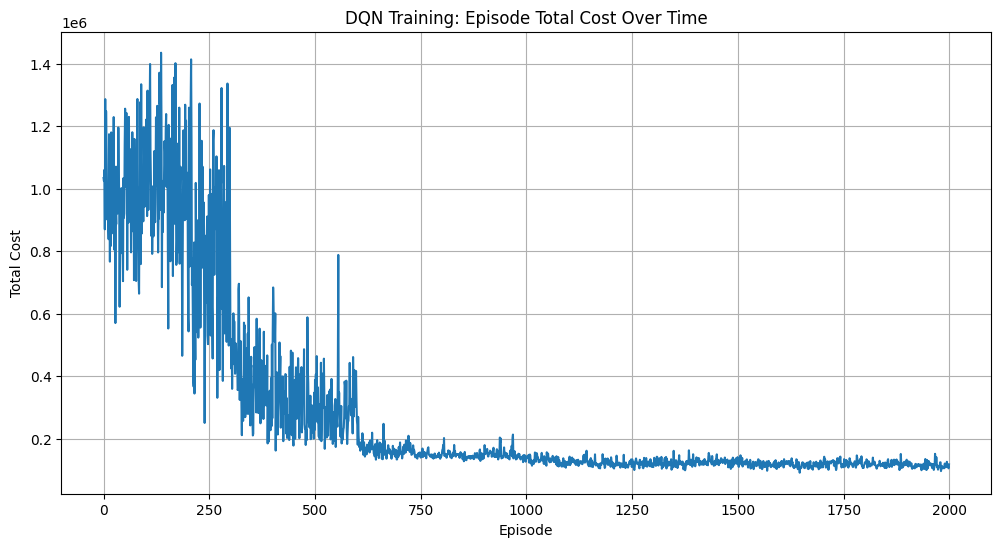


Evaluating trained DQN policy...
DQN Evaluation Results:


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,132508.75,27588.75,0.08,0.01


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

# State dimensions from continuous_state_normalization
# inv (3) + pipeline (12) + demand_hist (21) + day (1) + capacity (1) = 38
STATE_DIM = 38
ACTION_DIM = NUM_TOTAL_ACTIONS # Same as tabular: 11^3 = 1331

# DQN Hyperparameters
DQN_LEARNING_RATE = 0.001
BATCH_SIZE = 64
BUFFER_SIZE = 100000
TARGET_UPDATE_FREQ = 100 # C steps

# Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

# DQN Network
class DQNNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def forward(self, x):
        return self.net(x)

# Training function for DQN
def train_dqn(
    env: IndustrialInventoryEnv,
    num_episodes: int,
    alpha: float,
    gamma: float,
    epsilon: float,
    epsilon_decay: float,
    min_epsilon: float,
    batch_size: int,
    buffer_size: int,
    target_update_freq: int,
) -> tuple[nn.Module, list[float]]:
    """Trains a DQN agent on the Industrial Inventory environment."""

    policy_net = DQNNetwork(STATE_DIM, ACTION_DIM)
    target_net = DQNNetwork(STATE_DIM, ACTION_DIM)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval() # Set target network to evaluation mode

    optimizer = optim.Adam(policy_net.parameters(), lr=alpha)
    criterion = nn.MSELoss() # L(theta) as mean squared error
    replay_buffer = ReplayBuffer(buffer_size)

    episode_costs = []
    current_epsilon = epsilon

    for episode in range(num_episodes):
        observation, _ = env.reset(seed=SEED)
        state = continuous_state_normalization(observation)
        state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

        terminated = False
        truncated = False
        episode_total_cost = 0.0

        for t in range(T): # Max 50 days per episode
            # Epsilon-greedy action selection
            if np.random.rand() < current_epsilon:
                action_idx = np.random.randint(0, ACTION_DIM)
            else:
                with torch.no_grad():
                    action_idx = policy_net(state_tensor).argmax(1).item()

            # Convert single action index to environment's MultiDiscrete indices
            multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
            # Convert MultiDiscrete indices to actual quantities
            quantities = action_index_to_quantity(multi_discrete_action)
            # Convert quantities to environment's internal action indices for `env.step`
            env_action_indices = env.quantities_to_action_indices(quantities)

            # Take action and observe next state and reward
            next_observation, reward, terminated, truncated, info = env.step(env_action_indices)
            next_state = continuous_state_normalization(next_observation)
            episode_total_cost += info["costs"]["daily_total"]

            # Store experience in replay buffer
            done = terminated or truncated
            replay_buffer.push(state, action_idx, reward, next_state, done)

            state = next_state
            state_tensor = torch.FloatTensor(state).unsqueeze(0)

            if done:
                break

            # Train the network if enough samples in buffer
            if len(replay_buffer) > batch_size:
                experiences = replay_buffer.sample(batch_size)
                states, actions, rewards, next_states, dones = zip(*experiences)

                states = torch.FloatTensor(np.array(states))
                actions = torch.LongTensor(actions).unsqueeze(1)
                rewards = torch.FloatTensor(rewards).unsqueeze(1)
                next_states = torch.FloatTensor(np.array(next_states))
                dones = torch.FloatTensor(dones).unsqueeze(1)

                # Compute Q(s, a; theta)
                q_values = policy_net(states).gather(1, actions)

                # Compute target Q-values: r + gamma * max_a' Q(s', a'; theta^-)
                with torch.no_grad():
                    next_q_values = target_net(next_states).max(1)[0].unsqueeze(1)
                    target_q_values = rewards + (gamma * next_q_values * (1 - dones))

                # Compute loss and update policy network
                loss = criterion(q_values, target_q_values)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        episode_costs.append(episode_total_cost)

        # Update target network
        if (episode + 1) % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

        # Decay epsilon
        current_epsilon = max(min_epsilon, current_epsilon * epsilon_decay)

        if (episode + 1) % 100 == 0 or episode == num_episodes - 1:
            print(f"Episode {episode + 1}/{num_episodes}, Total Cost: {episode_total_cost:.2f}, Epsilon: {current_epsilon:.4f}")

    return policy_net, episode_costs

# Inference policy for DQN
def dqn_inference_policy(observation: dict, policy_net: nn.Module) -> list[int]:
    """Inference policy for DQN, taking observation and returning quantities."""
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0)

    policy_net.eval() # Set policy network to evaluation mode
    with torch.no_grad():
        action_idx = policy_net(state_tensor).argmax(1).item()
    policy_net.train() # Set policy network back to training mode if it's used elsewhere

    # Convert single action index to MultiDiscrete action tuple
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)

    # Convert MultiDiscrete indices to actual quantities
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# Train the DQN agent
print("Starting DQN training...")

training_env_dqn = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

trained_dqn_policy_net, dqn_training_episode_costs = train_dqn(
    env=training_env_dqn,
    num_episodes=2000, # Number of training episodes
    alpha=DQN_LEARNING_RATE,
    gamma=GAMMA,
    epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY,
    min_epsilon=MIN_EPSILON,
    batch_size=BATCH_SIZE,
    buffer_size=BUFFER_SIZE,
    target_update_freq=TARGET_UPDATE_FREQ,
)

print("DQN training finished.")

# Plot learning curve
plt.figure(figsize=(12, 6))
plt.plot(dqn_training_episode_costs)
plt.title("DQN Training: Episode Total Cost Over Time")
plt.xlabel("Episode")
plt.ylabel("Total Cost")
plt.grid(True)
plt.show()

# Evaluate the trained DQN policy
print("\nEvaluating trained DQN policy...")

def dqn_policy_for_eval(observation: dict) -> list[int]:
    return dqn_inference_policy(observation, trained_dqn_policy_net)

dqn_results = evaluate_policy(
    policy=dqn_policy_for_eval,
    student_config=student_config,
    num_episodes=20,
    scenario_modes=["random", "seasonal"],
    domain_randomization=True,
)

print("DQN Evaluation Results:")
display(dqn_results)


In [ ]:
# @title Save DQN model

# Ensure the trained_dqn_policy_net is available from previous training steps
# (Assuming it's a globally accessible variable after training)

model_save_path = 'dqn_model.pth'
torch.save(trained_dqn_policy_net.state_dict(), model_save_path)
print(f"Trained DQN model saved to {model_save_path}")

Trained DQN model saved to dqn_model.pth


In [ ]:
# @title Inference using saved DQN model

import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

# --- Constants (must match values used during training) ---
# These values are derived from your notebook's global constants and environment setup.
# Ensure these match the definitions in your training notebook.
STATE_DIM = 38  # inv(3) + pipeline(12) + demand_hist(21) + day(1) + capacity(1)
ACTION_DIM = 1331 # 11^3 (11 choices per product, 3 products)
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
NUM_PRODUCTS = 3
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES)

# --- Helper Functions (copied from notebook for self-containment) ---
def continuous_state_normalization(obs: dict) -> np.ndarray:
    """Normalizes and flattens the raw observation dictionary into a continuous vector."""
    inventory_norm = obs["inventory"].astype(float) / 500.0
    pipeline_norm = obs["arrival_pipeline"].flatten().astype(float) / 200.0
    demand_history_norm = obs["demand_history"].flatten().astype(float) / 100.0
    day_norm = obs["day"].astype(float) / 50.0
    capacity_utilisation_norm = obs["capacity_utilisation"].astype(float)
    return np.concatenate([
        inventory_norm,
        pipeline_norm,
        demand_history_norm,
        day_norm,
        capacity_utilisation_norm
    ], axis=0)

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    """Converts a single integer action index to a MultiDiscrete action tuple."""
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    """Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]"""
    return [int(QUANTITIES[idx]) for idx in action_indices]

# --- DQN Network Definition (copied from notebook's DQNNetwork class) ---
class DQNNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Global Model Instance and Loading for policy.py ---
# This model will be loaded once when the policy.py module is imported.
dqn_policy_model = DQNNetwork(STATE_DIM, ACTION_DIM)

# Define the path to your saved model file.
# In a submission, 'dqn_model.pth' should be in the same directory as 'policy.py'
model_path = Path('./dqn_model.pth') # Assuming model is saved in the same directory

if model_path.exists():
    try:
        # Load the model's state_dict. map_location='cpu' is good practice for deployment.
        dqn_policy_model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
        print(f"DQN model loaded successfully from {model_path}")
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")
        print("DQN model initialized with random weights instead.")
else:
    print(f"Warning: Model file not found at {model_path}. DQN model initialized with random weights.")
    print("Please ensure your trained 'dqn_model.pth' is saved in the correct location.")

dqn_policy_model.eval() # Set the model to evaluation mode; no gradients needed during inference.

# --- Main Policy Function for Submission ---
def run_policy(observation: dict) -> list[int]:
    """Return order quantities for Products 1, 2 and 3 using the trained DQN policy."""

    # Preprocess the observation
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

    # Perform inference
    with torch.no_grad(): # Disable gradient calculations for efficiency
        action_idx = dqn_policy_model(state_tensor).argmax(1).item()

    # Convert the action index back to quantities
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# --- Example Usage (This block is for testing and would NOT be in the final policy.py submission) ---
if __name__ == '__main__':
    print("\n--- Testing run_policy function for DQN ---")
    dummy_observation = {
        'inventory': np.array([50, 60, 70], dtype=np.int32),
        'arrival_pipeline': np.zeros((3, 4), dtype=np.int32),
        'demand_history': np.zeros((7, 3), dtype=np.int32),
        'day': np.array([10], dtype=np.int32),
        'capacity_utilisation': np.array([0.5], dtype=np.float32)
    }
    recommended_quantities = run_policy(dummy_observation)
    print(f"Recommended quantities for dummy observation: {recommended_quantities}")

DQN model loaded successfully from dqn_model.pth

--- Testing run_policy function for DQN ---
Recommended quantities for dummy observation: [100, 10, 50]


## Double DQN

Double DQN addresses the overestimation bias of Q-values inherent in standard DQN by decoupling the action selection from the action evaluation in the target Q-value calculation. Instead of using the target network to both select and evaluate the next action, Double DQN uses the **policy network** to select the best action in the next state and the **target network** to evaluate the Q-value of that selected action.

The loss function for Double DQN is a modification of the standard DQN loss:

$$L(\theta) = \mathbb{E}_{(s, a, r, s') \sim \mathcal{D}} \left[ \left( r + \gamma Q(s', \arg\max_{a'} Q(s', a'; \theta); \theta^-) - Q(s, a; \theta) \right)^2 \right]$$

Where:
*   $Q(s, a; \theta)$ is the Q-value from the **policy network** for the current state-action pair.
*   $Q(s', \arg\max_{a'} Q(s', a'; \theta); \theta^-)$ is the target Q-value:
    *   $\arg\max_{a'} Q(s', a'; \theta)$ uses the **policy network** (with parameters $\theta$) to select the best action $a'$ in the next state $s'$.
    *   $Q(s', \text{selected } a'; \theta^-)$ then uses the **target network** (with parameters $\theta^-$) to evaluate the Q-value of that selected action.

$\\theta^-$ denotes parameters of the target network updated every $C$ steps, similar to standard DQN.

Starting Double DQN training...
Episode 100/2000, Total Cost: 891715.00, Epsilon: 0.6058
Episode 200/2000, Total Cost: 1208392.50, Epsilon: 0.3670
Episode 300/2000, Total Cost: 729460.00, Epsilon: 0.2223
Episode 400/2000, Total Cost: 432842.50, Epsilon: 0.1347
Episode 500/2000, Total Cost: 381420.00, Epsilon: 0.0816
Episode 600/2000, Total Cost: 306760.00, Epsilon: 0.0494
Episode 700/2000, Total Cost: 346245.00, Epsilon: 0.0299
Episode 800/2000, Total Cost: 155405.00, Epsilon: 0.0181
Episode 900/2000, Total Cost: 176815.00, Epsilon: 0.0110
Episode 1000/2000, Total Cost: 163780.00, Epsilon: 0.0100
Episode 1100/2000, Total Cost: 172432.50, Epsilon: 0.0100
Episode 1200/2000, Total Cost: 152695.00, Epsilon: 0.0100
Episode 1300/2000, Total Cost: 146000.00, Epsilon: 0.0100
Episode 1400/2000, Total Cost: 139195.00, Epsilon: 0.0100
Episode 1500/2000, Total Cost: 147770.00, Epsilon: 0.0100
Episode 1600/2000, Total Cost: 159535.00, Epsilon: 0.0100
Episode 1700/2000, Total Cost: 152540.00, Epsilo

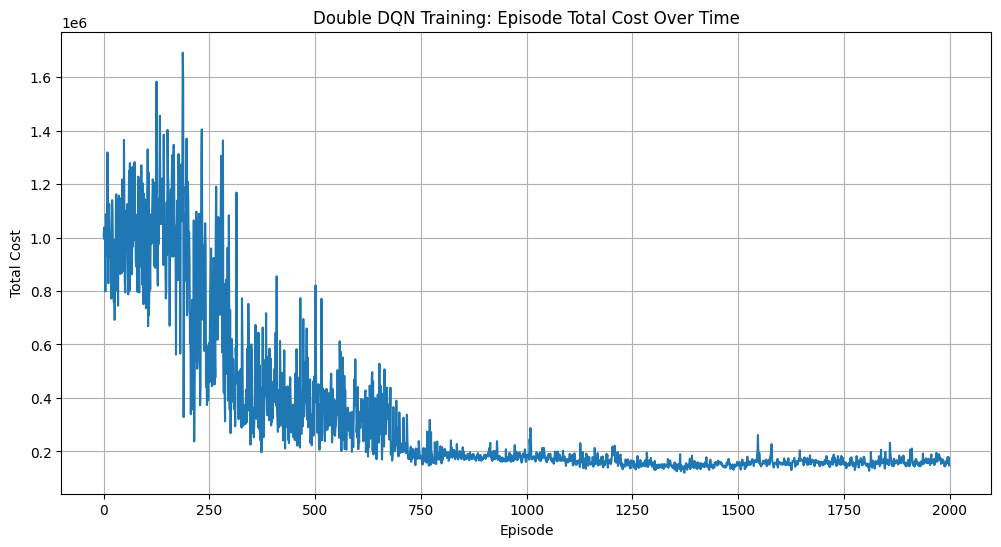


Evaluating trained Double DQN policy...
Double DQN Evaluation Results:


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,174133.75,27308.75,0.04,0.03


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

# Training function for Double DQN
def train_double_dqn(
    env: IndustrialInventoryEnv,
    num_episodes: int,
    alpha: float,
    gamma: float,
    epsilon: float,
    epsilon_decay: float,
    min_epsilon: float,
    batch_size: int,
    buffer_size: int,
    target_update_freq: int,
) -> tuple[nn.Module, list[float]]:
    """Trains a Double DQN agent on the Industrial Inventory environment."""

    policy_net = DQNNetwork(STATE_DIM, ACTION_DIM)
    target_net = DQNNetwork(STATE_DIM, ACTION_DIM)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval() # Set target network to evaluation mode

    optimizer = optim.Adam(policy_net.parameters(), lr=alpha)
    criterion = nn.MSELoss() # L(theta) as mean squared error
    replay_buffer = ReplayBuffer(buffer_size)

    episode_costs = []
    current_epsilon = epsilon

    for episode in range(num_episodes):
        observation, _ = env.reset(seed=SEED)
        state = continuous_state_normalization(observation)
        state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

        terminated = False
        truncated = False
        episode_total_cost = 0.0

        for t in range(T): # Max 50 days per episode
            # Epsilon-greedy action selection
            if np.random.rand() < current_epsilon:
                action_idx = np.random.randint(0, ACTION_DIM)
            else:
                with torch.no_grad():
                    action_idx = policy_net(state_tensor).argmax(1).item()

            # Convert single action index to environment's MultiDiscrete indices
            multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
            # Convert MultiDiscrete indices to actual quantities
            quantities = action_index_to_quantity(multi_discrete_action)
            # Convert quantities to environment's internal action indices for `env.step`
            env_action_indices = env.quantities_to_action_indices(quantities)

            # Take action and observe next state and reward
            next_observation, reward, terminated, truncated, info = env.step(env_action_indices)
            next_state = continuous_state_normalization(next_observation)
            episode_total_cost += info["costs"]["daily_total"]

            # Store experience in replay buffer
            done = terminated or truncated
            replay_buffer.push(state, action_idx, reward, next_state, done)

            state = next_state
            state_tensor = torch.FloatTensor(state).unsqueeze(0)

            if done:
                break

            # Train the network if enough samples in buffer
            if len(replay_buffer) > batch_size:
                experiences = replay_buffer.sample(batch_size)
                states, actions, rewards, next_states, dones = zip(*experiences)

                states = torch.FloatTensor(np.array(states))
                actions = torch.LongTensor(actions).unsqueeze(1)
                rewards = torch.FloatTensor(rewards).unsqueeze(1)
                next_states = torch.FloatTensor(np.array(next_states))
                dones = torch.FloatTensor(dones).unsqueeze(1)

                # Compute Q(s, a; theta)
                q_values = policy_net(states).gather(1, actions)

                # Compute target Q-values using Double DQN update
                with torch.no_grad():
                    # Select best action from policy_net
                    next_action_selection = policy_net(next_states).argmax(1).unsqueeze(1)
                    # Evaluate that action using target_net
                    next_q_values = target_net(next_states).gather(1, next_action_selection)
                    target_q_values = rewards + (gamma * next_q_values * (1 - dones))

                # Compute loss and update policy network
                loss = criterion(q_values, target_q_values)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        episode_costs.append(episode_total_cost)

        # Update target network
        if (episode + 1) % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

        # Decay epsilon
        current_epsilon = max(min_epsilon, current_epsilon * epsilon_decay)

        if (episode + 1) % 100 == 0 or episode == num_episodes - 1:
            print(f"Episode {episode + 1}/{num_episodes}, Total Cost: {episode_total_cost:.2f}, Epsilon: {current_epsilon:.4f}")

    return policy_net, episode_costs

# Inference policy for Double DQN (same as DQN inference)
def double_dqn_inference_policy(observation: dict, policy_net: nn.Module) -> list[int]:
    """Inference policy for Double DQN, taking observation and returning quantities."""
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0)

    policy_net.eval() # Set policy network to evaluation mode
    with torch.no_grad():
        action_idx = policy_net(state_tensor).argmax(1).item()
    policy_net.train() # Set policy network back to training mode if it's used elsewhere

    # Convert single action index to MultiDiscrete action tuple
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)

    # Convert MultiDiscrete indices to actual quantities
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# Train the Double DQN agent
print("Starting Double DQN training...")

training_env_double_dqn = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

trained_double_dqn_policy_net, double_dqn_training_episode_costs = train_double_dqn(
    env=training_env_double_dqn,
    num_episodes=2000, # Number of training episodes
    alpha=DQN_LEARNING_RATE,
    gamma=GAMMA,
    epsilon=EPSILON,
    epsilon_decay=EPSILON_DECAY,
    min_epsilon=MIN_EPSILON,
    batch_size=BATCH_SIZE,
    buffer_size=BUFFER_SIZE,
    target_update_freq=TARGET_UPDATE_FREQ,
)

print("Double DQN training finished.")

# Plot learning curve
plt.figure(figsize=(12, 6))
plt.plot(double_dqn_training_episode_costs)
plt.title("Double DQN Training: Episode Total Cost Over Time")
plt.xlabel("Episode")
plt.ylabel("Total Cost")
plt.grid(True)
plt.show()

# Evaluate the trained Double DQN policy
print("\nEvaluating trained Double DQN policy...")

def double_dqn_policy_for_eval(observation: dict) -> list[int]:
    return double_dqn_inference_policy(observation, trained_double_dqn_policy_net)

double_dqn_results = evaluate_policy(
    policy=double_dqn_policy_for_eval,
    student_config=student_config,
    num_episodes=20,
    scenario_modes=["random", "seasonal"],
    domain_randomization=True,
)

print("Double DQN Evaluation Results:")
display(double_dqn_results)


In [ ]:
# @title Save Double DQN model

model_save_path = 'double_dqn_model.pth'
torch.save(trained_dqn_policy_net.state_dict(), model_save_path)
print(f"Trained Double DQN model saved to {model_save_path}")

Trained Double DQN model saved to double_dqn_model.pth


In [ ]:
# @title Inference using saved Double DQN model

import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

# --- Constants (must match values used during training) ---
# These values are derived from your notebook's global constants and environment setup.
# Ensure these match the definitions in your training notebook.
STATE_DIM = 38  # inv(3) + pipeline(12) + demand_hist(21) + day(1) + capacity(1)
ACTION_DIM = 1331 # 11^3 (11 choices per product, 3 products)
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
NUM_PRODUCTS = 3
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES)

# --- Helper Functions (copied from notebook for self-containment) ---
def continuous_state_normalization(obs: dict) -> np.ndarray:
    """Normalizes and flattens the raw observation dictionary into a continuous vector."""
    inventory_norm = obs["inventory"].astype(float) / 500.0
    pipeline_norm = obs["arrival_pipeline"].flatten().astype(float) / 200.0
    demand_history_norm = obs["demand_history"].flatten().astype(float) / 100.0
    day_norm = obs["day"].astype(float) / 50.0
    capacity_utilisation_norm = obs["capacity_utilisation"].astype(float)
    return np.concatenate([
        inventory_norm,
        pipeline_norm,
        demand_history_norm,
        day_norm,
        capacity_utilisation_norm
    ], axis=0)

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    """Converts a single integer action index to a MultiDiscrete action tuple."""
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    """Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]"""
    return [int(QUANTITIES[idx]) for idx in action_indices]

# --- DQN Network Definition (copied from notebook's DQNNetwork class) ---
class DQNNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def forward(self, x):
        return self.net(x)

# --- Global Model Instance and Loading for policy.py ---
# This model will be loaded once when the policy.py module is imported.
dqn_policy_model = DQNNetwork(STATE_DIM, ACTION_DIM)

# Define the path to your saved model file.
# In a submission, 'double_dqn_model.pth' should be in the same directory as 'policy.py'
model_path = Path('./double_dqn_model.pth') # Assuming model is saved in the same directory

if model_path.exists():
    try:
        # Load the model's state_dict. map_location='cpu' is good practice for deployment.
        dqn_policy_model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
        print(f"Double DQN model loaded successfully from {model_path}")
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")
        print("Double DQN model initialized with random weights instead.")
else:
    print(f"Warning: Model file not found at {model_path}. Double DQN model initialized with random weights.")
    print("Please ensure your trained 'double_dqn_model.pth' is saved in the correct location.")

dqn_policy_model.eval() # Set the model to evaluation mode; no gradients needed during inference.

# --- Main Policy Function for Submission ---
def run_policy(observation: dict) -> list[int]:
    """Return order quantities for Products 1, 2 and 3 using the trained Double DQN policy."""

    # Preprocess the observation
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

    # Perform inference
    with torch.no_grad(): # Disable gradient calculations for efficiency
        action_idx = dqn_policy_model(state_tensor).argmax(1).item()

    # Convert the action index back to quantities
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# --- Example Usage (This block is for testing and would NOT be in the final policy.py submission) ---
if __name__ == '__main__':
    print("\n--- Testing run_policy function for DQN ---")
    dummy_observation = {
        'inventory': np.array([50, 60, 70], dtype=np.int32),
        'arrival_pipeline': np.zeros((3, 4), dtype=np.int32),
        'demand_history': np.zeros((7, 3), dtype=np.int32),
        'day': np.array([10], dtype=np.int32),
        'capacity_utilisation': np.array([0.5], dtype=np.float32)
    }
    recommended_quantities = run_policy(dummy_observation)
    print(f"Recommended quantities for dummy observation: {recommended_quantities}")

Double DQN model loaded successfully from double_dqn_model.pth

--- Testing run_policy function for DQN ---
Recommended quantities for dummy observation: [100, 10, 50]


## PPO

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# PPO Hyperparameters (can be tuned)
PPO_LEARNING_RATE = 0.0003
PPO_GAMMA = 0.99
PPO_GAE_LAMBDA = 0.95
PPO_CLIP_EPSILON = 0.2
PPO_EPOCHS = 10 # Number of policy update epochs per data collection
PPO_BATCH_SIZE = 64 # Mini-batch size for policy updates
PPO_STEPS_PER_EPISODE = T # Collect data for one episode at a time
PPO_ENTROPY_COEFF = 0.01 # New: Entropy coefficient for exploration

# Actor-Critic Network
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.shared_net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU()
        )

        self.actor_net = nn.Sequential(
            nn.Linear(256, action_dim),
            nn.Softmax(dim=-1) # Output probabilities for each action
        )

        self.critic_net = nn.Sequential(
            nn.Linear(256, 1) # Output state value
        )

    def forward(self, x):
        shared_features = self.shared_net(x)
        action_probs = self.actor_net(shared_features)
        state_values = self.critic_net(shared_features)
        return action_probs, state_values

# Function to compute Generalized Advantage Estimation (GAE)
def compute_gae(rewards, values, dones, gamma, gae_lambda):
    advantages = []
    # Convert rewards, values, and dones to numpy arrays if they are tensors
    rewards_np = rewards.squeeze().cpu().numpy() if isinstance(rewards, torch.Tensor) else rewards
    values_np = values.squeeze().cpu().numpy() if isinstance(values, torch.Tensor) else values
    dones_np = dones.squeeze().cpu().numpy() if isinstance(dones, torch.Tensor) else dones

    next_advantage = 0
    # Iterate backwards through the trajectory to compute GAE
    # The last value in 'values_np' is V(S_T), which is used to calculate delta for S_{T-1}.
    # So, values_np[i+1] is needed for rewards_np[i].
    # The loop should go from T-1 down to 0.
    for i in reversed(range(len(rewards_np))):
        # For the very last step (i = len(rewards_np) - 1), values_np[i+1] would correspond to V(S_T)
        # which is the last element added to the `values` list before conversion to tensor.
        # dones_np[i] is 1 if the episode terminated at step i, 0 otherwise.
        delta = rewards_np[i] + gamma * values_np[i+1] * (1 - dones_np[i]) - values_np[i]
        advantage = delta + gamma * gae_lambda * (1 - dones_np[i]) * next_advantage
        advantages.insert(0, advantage)
        next_advantage = advantage
    return torch.tensor(advantages, dtype=torch.float32)

# PPO training function
def train_ppo(
    env: IndustrialInventoryEnv,
    num_episodes: int,
    ppo_learning_rate: float,
    ppo_gamma: float,
    ppo_gae_lambda: float,
    ppo_clip_epsilon: float,
    ppo_epochs: int,
    ppo_batch_size: int,
    ppo_steps_per_episode: int,
    ppo_entropy_coeff: float, # New parameter
) -> tuple[nn.Module, list[float]]:
    """Trains a PPO agent on the Industrial Inventory environment."""

    policy_net = ActorCritic(STATE_DIM, ACTION_DIM)
    optimizer = optim.Adam(policy_net.parameters(), lr=ppo_learning_rate)

    episode_costs = []

    for episode in range(num_episodes):
        states, actions, rewards, next_states, dones, old_log_probs, values = [], [], [], [], [], [], []

        observation, _ = env.reset(seed=SEED)
        state = continuous_state_normalization(observation)
        state_tensor = torch.FloatTensor(state).unsqueeze(0)

        episode_total_cost = 0.0

        # Collect experience for one episode
        for t in range(ppo_steps_per_episode):
            action_probs, value = policy_net(state_tensor)
            dist = Categorical(action_probs)
            action_idx = dist.sample()
            log_prob = dist.log_prob(action_idx)

            # Convert single action index to environment's MultiDiscrete indices
            multi_discrete_action = map_action_index_to_multi_discrete(action_idx.item())
            quantities = action_index_to_quantity(multi_discrete_action)
            env_action_indices = env.quantities_to_action_indices(quantities)

            next_observation, reward, terminated, truncated, info = env.step(env_action_indices)
            next_state = continuous_state_normalization(next_observation)
            episode_total_cost += info["costs"]["daily_total"]

            states.append(state)
            actions.append(action_idx)
            rewards.append(reward)
            next_states.append(next_state)
            dones.append(terminated or truncated)
            old_log_probs.append(log_prob)
            values.append(value.detach().squeeze().item())

            state = next_state
            state_tensor = torch.FloatTensor(state).unsqueeze(0)

            if terminated or truncated:
                break

        episode_costs.append(episode_total_cost)

        # Add final next_state value for GAE calculation
        # This assumes that if the episode terminates, the value of the next state (which doesn't exist) is 0.
        # The GAE function handles the 'done' flag, so V(S_T) is correctly incorporated.
        # If the episode truncates before T steps, we still need to estimate V(S_T).
        if not (terminated or truncated): # If episode did not naturally terminate or truncate
            _, final_value = policy_net(state_tensor) # current state is S_T
            values.append(final_value.detach().squeeze().item())
        else:
            values.append(0.0) # V(S_T) is 0 if episode truly ended

        # Convert lists to tensors
        # Ensure all tensors are detached from the graph before computing advantages for multiple epochs
        states = torch.FloatTensor(np.array(states))
        actions = torch.cat(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        # next_states are not directly used in the PPO update after GAE
        dones = torch.FloatTensor(dones).unsqueeze(1)
        old_log_probs = torch.cat(old_log_probs).unsqueeze(1).detach() # Detach old_log_probs
        values = torch.FloatTensor(values).unsqueeze(1)

        # Compute advantages and returns using GAE
        advantages = compute_gae(rewards, values, dones, ppo_gamma, ppo_gae_lambda).detach() # Detach advantages
        # returns = advantages + values[:-1] # V(s) + A(s,a) = Q(s,a), but GAE returns are like target values
        # Correct returns calculation: The returns for a trajectory (s_0, ..., s_T-1) need target values (R_0, ..., R_T-1).
        # GAE is already a good estimate of the advantage. The target value for the critic loss is GAE + V(s).
        # So, 'returns' should be the target values, not just advantages.
        returns = advantages + values[:-1].squeeze(1) # Ensure correct shape for addition
        returns = returns.unsqueeze(1).detach() # Detach returns and ensure correct shape

        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # PPO Update (multiple epochs on collected data)
        for _ in range(ppo_epochs):
            # Create mini-batches
            indices = torch.randperm(len(states))
            for start_idx in range(0, len(states), ppo_batch_size):
                batch_indices = indices[start_idx : start_idx + ppo_batch_size]
                s_batch = states[batch_indices]
                a_batch = actions[batch_indices]
                r_batch = returns[batch_indices] # Target values for critic
                adv_batch = advantages[batch_indices]
                old_log_probs_batch = old_log_probs[batch_indices]

                # Get new action probabilities and state values
                new_action_probs, new_values = policy_net(s_batch)
                new_dist = Categorical(new_action_probs)
                new_log_probs = new_dist.log_prob(a_batch.squeeze(1)).unsqueeze(1)

                # Calculate probability ratio
                ratio = torch.exp(new_log_probs - old_log_probs_batch)

                # Clipped Surrogate Objective
                surr1 = ratio * adv_batch
                surr2 = torch.clamp(ratio, 1.0 - ppo_clip_epsilon, 1.0 + ppo_clip_epsilon) * adv_batch
                actor_loss = -torch.min(surr1, surr2).mean() # Negative sign for maximization

                # Calculate entropy for exploration bonus
                entropy = new_dist.entropy().mean()

                # Critic Loss (MSE)
                # Ensure new_values and r_batch have compatible shapes (batch_size, 1)
                critic_loss = nn.MSELoss()(new_values, r_batch)

                # Total Loss with entropy bonus
                loss = actor_loss + 0.5 * critic_loss - ppo_entropy_coeff * entropy # Subtract entropy for maximization

                # Update network
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if (episode + 1) % 100 == 0 or episode == num_episodes - 1:
            print(f"Episode {episode + 1}/{num_episodes}, Total Cost: {episode_total_cost:.2f}")

    return policy_net, episode_costs

# Inference policy for PPO
def ppo_inference_policy(observation: dict, policy_net: nn.Module) -> list[int]:
    """Inference policy for PPO, taking observation and returning quantities."""
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0)

    policy_net.eval() # Set policy network to evaluation mode
    with torch.no_grad():
        action_probs, _ = policy_net(state_tensor)
        dist = Categorical(action_probs)
        action_idx = dist.sample().item()
    policy_net.train() # Set policy network back to training mode if it's used elsewhere

    # Convert single action index to MultiDiscrete action tuple
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)

    # Convert MultiDiscrete indices to actual quantities
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

Starting PPO training...
Episode 100/2000, Total Cost: 1432485.00
Episode 200/2000, Total Cost: 1432485.00
Episode 300/2000, Total Cost: 1430650.00
Episode 400/2000, Total Cost: 1394417.50
Episode 500/2000, Total Cost: 1420237.50
Episode 600/2000, Total Cost: 1435940.00
Episode 700/2000, Total Cost: 1435940.00
Episode 800/2000, Total Cost: 1435940.00
Episode 900/2000, Total Cost: 1435940.00
Episode 1000/2000, Total Cost: 1426062.50
Episode 1100/2000, Total Cost: 1426062.50
Episode 1200/2000, Total Cost: 1426062.50
Episode 1300/2000, Total Cost: 1426062.50
Episode 1400/2000, Total Cost: 1426062.50
Episode 1500/2000, Total Cost: 1426062.50
Episode 1600/2000, Total Cost: 1426062.50
Episode 1700/2000, Total Cost: 1426062.50
Episode 1800/2000, Total Cost: 1426062.50
Episode 1900/2000, Total Cost: 1426062.50
Episode 2000/2000, Total Cost: 1426062.50
PPO training finished.


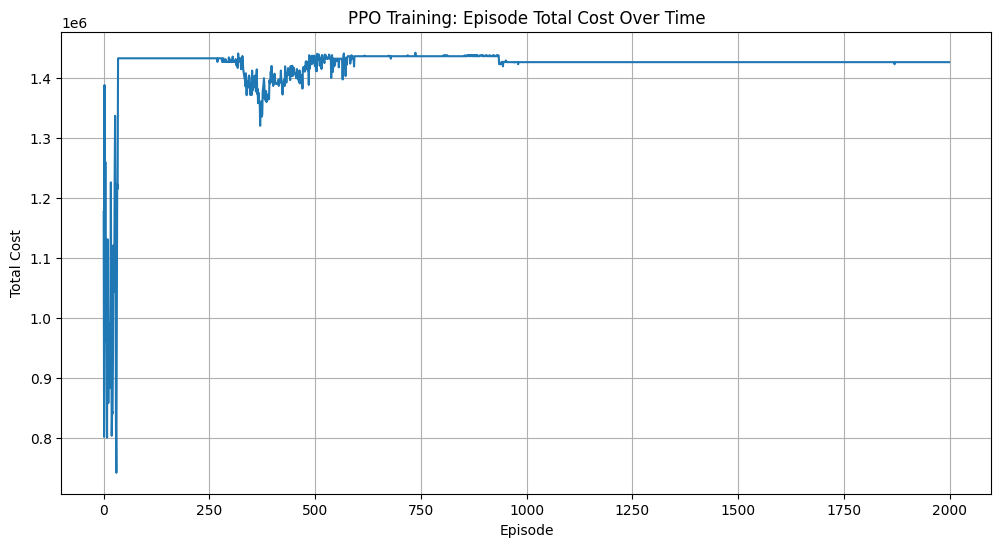


Evaluating trained PPO policy...
PPO Evaluation Results:


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,1396236.25,29826.25,0.14,0.92


In [ ]:
# Train the PPO agent
print("Starting PPO training...")

training_env_ppo = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

trained_ppo_policy_net, ppo_training_episode_costs = train_ppo(
    env=training_env_ppo,
    num_episodes=2000, # Number of training episodes
    ppo_learning_rate=PPO_LEARNING_RATE,
    ppo_gamma=PPO_GAMMA,
    ppo_gae_lambda=PPO_GAE_LAMBDA,
    ppo_clip_epsilon=PPO_CLIP_EPSILON,
    ppo_epochs=PPO_EPOCHS,
    ppo_batch_size=PPO_BATCH_SIZE,
    ppo_steps_per_episode=PPO_STEPS_PER_EPISODE,
    ppo_entropy_coeff=PPO_ENTROPY_COEFF, # Pass new hyperparameter
)

print("PPO training finished.")

# Plot learning curve
plt.figure(figsize=(12, 6))
plt.plot(ppo_training_episode_costs)
plt.title("PPO Training: Episode Total Cost Over Time")
plt.xlabel("Episode")
plt.ylabel("Total Cost")
plt.grid(True)
plt.show()

# Evaluate the trained PPO policy
print("\nEvaluating trained PPO policy...")

def ppo_policy_for_eval(observation: dict) -> list[int]:
    return ppo_inference_policy(observation, trained_ppo_policy_net)

ppo_results = evaluate_policy(
    policy=ppo_policy_for_eval,
    student_config=student_config,
    num_episodes=20,
    scenario_modes=["random", "seasonal"],
    domain_randomization=True,
)

print("PPO Evaluation Results:")
display(ppo_results)

In [ ]:
# @title Save the PPO model
model_save_path = 'ppo_model.pth'
torch.save(trained_ppo_policy_net.state_dict(), model_save_path)
print(f"Trained PPO model saved to {model_save_path}")

Trained PPO model saved to ppo_model.pth


In [ ]:
# @title Inference by reading from PPO saved model
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Categorical
from pathlib import Path

# --- Constants (must match values used during training) ---
# These values are derived from your notebook's global constants and environment setup.
# Ensure these match the definitions in your training notebook.
STATE_DIM = 38  # inv(3) + pipeline(12) + demand_hist(21) + day(1) + capacity(1)
ACTION_DIM = 1331 # 11^3 (11 choices per product, 3 products)
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
NUM_PRODUCTS = 3
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES)

# --- Helper Functions (copied from notebook for self-containment) ---
def continuous_state_normalization(obs: dict) -> np.ndarray:
    """Normalizes and flattens the raw observation dictionary into a continuous vector."""
    inventory_norm = obs["inventory"].astype(float) / 500.0
    pipeline_norm = obs["arrival_pipeline"].flatten().astype(float) / 200.0
    demand_history_norm = obs["demand_history"].flatten().astype(float) / 100.0
    day_norm = obs["day"].astype(float) / 50.0
    capacity_utilisation_norm = obs["capacity_utilisation"].astype(float)
    return np.concatenate([
        inventory_norm,
        pipeline_norm,
        demand_history_norm,
        day_norm,
        capacity_utilisation_norm
    ], axis=0)

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    """Converts a single integer action index to a MultiDiscrete action tuple."""
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    """Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]"""
    return [int(QUANTITIES[idx]) for idx in action_indices]

# --- PPO Model Definition (copied from notebook's ActorCritic class) ---
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.shared_net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU()
        )

        self.actor_net = nn.Sequential(
            nn.Linear(256, action_dim),
            nn.Softmax(dim=-1)
        )

        self.critic_net = nn.Sequential(
            nn.Linear(256, 1)
        )

    def forward(self, x):
        shared_features = self.shared_net(x)
        action_probs = self.actor_net(shared_features)
        state_values = self.critic_net(shared_features)
        return action_probs, state_values

ppo_policy_model = ActorCritic(STATE_DIM, ACTION_DIM)
model_path = Path('./ppo_model.pth') # Assuming model is saved in the same directory

if model_path.exists():
    try:
        # Load the model's state_dict. map_location='cpu' is good practice for deployment.
        ppo_policy_model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
        print(f"PPO model loaded successfully from {model_path}")
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")
        print("PPO model initialized with random weights instead.")
else:
    print(f"Warning: Model file not found at {model_path}. PPO model initialized with random weights.")
    print("Please ensure your trained 'ppo_model.pth' is saved in the correct location.")

ppo_policy_model.eval() # Set the model to evaluation mode; no gradients needed during inference.

# --- Main Policy Function for Submission ---
def run_policy(observation: dict) -> list[int]:
    """Return order quantities for Products 1, 2 and 3 using the trained PPO policy."""

    # Preprocess the observation
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

    # Perform inference
    with torch.no_grad(): # Disable gradient calculations for efficiency
        action_probs, _ = ppo_policy_model(state_tensor)
        dist = Categorical(action_probs)
        # For a deterministic policy during inference, you might use argmax:
        # action_idx = action_probs.argmax().item()
        # For the original PPO paper, it's often stochastic sampling even in inference:
        action_idx = dist.sample().item() # Sample an action from the distribution

    # Convert the action index back to quantities
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

PPO model loaded successfully from ppo_model.pth


## Actor 3 Critic (A3C) with 8 workers

Starting A3C training...


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([20, 20])) that is different to the input size (torch.Size([20, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Episode 100/2000, Total Cost: 324635.00, Steps in Rollout: 20
Episode 200/2000, Total Cost: 387607.50, Steps in Rollout: 20
Episode 300/2000, Total Cost: 370410.00, Steps in Rollout: 20
Episode 400/2000, Total Cost: 316417.50, Steps in Rollout: 20
Episode 500/2000, Total Cost: 222360.00, Steps in Rollout: 20
Episode 600/2000, Total Cost: 209055.00, Steps in Rollout: 20
Episode 700/2000, Total Cost: 287065.00, Steps in Rollout: 20
Episode 800/2000, Total Cost: 356720.00, Steps in Rollout: 20
Episode 900/2000, Total Cost: 353705.00, Steps in Rollout: 20
Episode 1000/2000, Total Cost: 337260.00, Steps in Rollout: 20
Episode 1100/2000, Total Cost: 515092.50, Steps in Rollout: 20
Episode 1200/2000, Total Cost: 510537.50, Steps in Rollout: 20
Episode 1300/2000, Total Cost: 486377.50, Steps in Rollout: 20
Episode 1400/2000, Total Cost: 521650.00, Steps in Rollout: 20
Episode 1500/2000, Total Cost: 484915.00, Steps in Rollout: 20
Episode 1600/2000, Total Cost: 146947.50, Steps in Rollout: 20
E

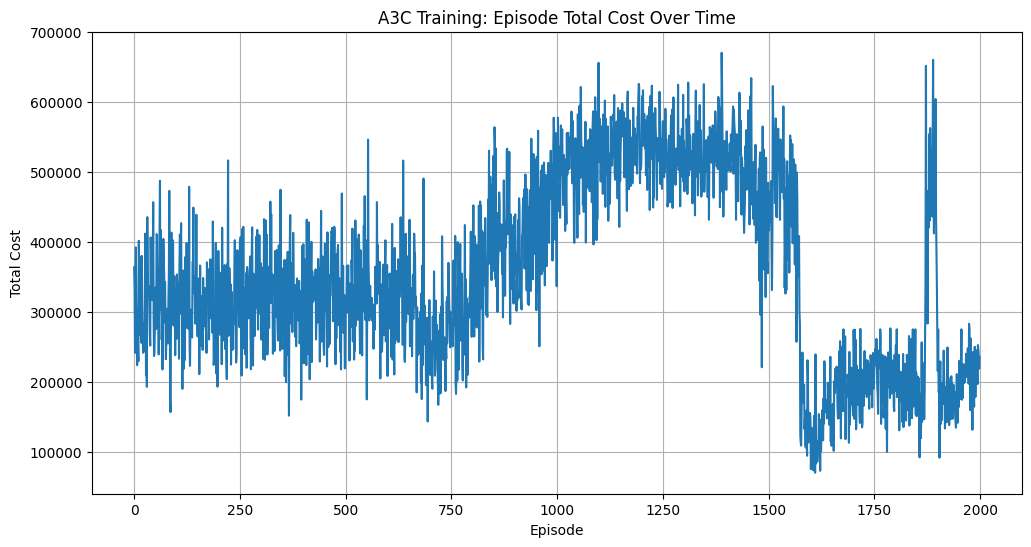


Evaluating trained A3C policy...
A3C Evaluation Results:


,Mean Episode Cost,Cost Standard Deviation,Stockout Frequency,Capacity Discard Event Rate
0,1048557.5,41174.677025,0.901,0.503


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import numpy as np
import multiprocessing # Imported for conceptual completeness, actual async not implemented in single cell

# A3C Hyperparameters based on user request:
# Learning Rate (alpha): 3e-4
# Discount Factor (gamma): 0.99
# Entropy coefficient (beta): 0.01
# Batch Size (n_steps for experience collection): 20
# GAE Lambda: 0.95 (common value, not explicitly provided for A3C but used with GAE)
A3C_LEARNING_RATE = 0.0003
A3C_GAMMA = 0.99
A3C_ENTROPY_COEFF = 0.01
A3C_N_STEPS = 20
A3C_GAE_LAMBDA = 0.95

# STATE_DIM and ACTION_DIM are already defined globally.
# STATE_DIM = 38
# ACTION_DIM = 1331

# Actor-Critic Network for A3C
# Architecture: Shared backbone (STATE_DIM -> 128), Actor head (128 -> ACTION_DIM), Critic head (128 -> 1)
class A3CActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        # Shared backbone: 38 -> 128
        self.shared_net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU()
        )

        # Actor head: 128 -> ACTION_DIM (1331) with Softmax for action probabilities
        self.actor_net = nn.Sequential(
            nn.Linear(128, action_dim),
            nn.Softmax(dim=-1) # Output probabilities for each action
        )

        # Critic head: 128 -> 1 for state value prediction
        self.critic_net = nn.Sequential(
            nn.Linear(128, 1) # Output state value
        )

    def forward(self, x):
        shared_features = self.shared_net(x)
        action_probs = self.actor_net(shared_features)
        state_values = self.critic_net(shared_features)
        return action_probs, state_values

# The 'compute_gae' function from the PPO implementation (cell aHynZCUpliJ1) is reused
# as it correctly calculates advantages and returns for n-step rollouts.

def train_a3c(
    env: IndustrialInventoryEnv,
    num_episodes: int,
    a3c_learning_rate: float,
    a3c_gamma: float,
    a3c_gae_lambda: float,
    a3c_entropy_coeff: float,
    a3c_n_steps: int,
) -> tuple[nn.Module, list[float]]:
    """Trains a single-worker A3C agent on the Industrial Inventory environment.

    This implementation simulates the core logic of a single A3C worker.
    True A3C involves multiple asynchronous workers updating a global model.
    For this in-notebook implementation, each 'episode' represents a training
    run for one worker, collecting 'n_steps' of experience and performing an update.
    """

    policy_net = A3CActorCritic(STATE_DIM, ACTION_DIM)
    optimizer = optim.Adam(policy_net.parameters(), lr=a3c_learning_rate)

    episode_costs = []

    for episode in range(num_episodes):
        observation, _ = env.reset(seed=SEED) # Reset env for each episode
        state = continuous_state_normalization(observation)

        episode_total_cost = 0.0
        # Buffers to store experience for the current n_steps rollout
        states_buffer, actions_buffer, rewards_buffer, values_buffer, log_probs_buffer, dones_buffer = [], [], [], [], [], []

        terminated = False
        truncated = False
        step_count = 0

        # Collect experience for A3C_N_STEPS or until episode termination/truncation
        while not terminated and not truncated and step_count < a3c_n_steps:
            state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

            action_probs, value = policy_net(state_tensor)
            dist = Categorical(action_probs)
            action_idx = dist.sample()
            log_prob = dist.log_prob(action_idx)

            # Convert single action index to environment's MultiDiscrete indices
            multi_discrete_action = map_action_index_to_multi_discrete(action_idx.item())
            quantities = action_index_to_quantity(multi_discrete_action)
            env_action_indices = env.quantities_to_action_indices(quantities)

            next_observation, reward, terminated, truncated, info = env.step(env_action_indices)
            next_state = continuous_state_normalization(next_observation)
            episode_total_cost += info["costs"]["daily_total"]

            # Store experience in buffers
            states_buffer.append(state)
            actions_buffer.append(action_idx)
            rewards_buffer.append(reward)
            values_buffer.append(value.detach().squeeze().item()) # Detach value for GAE computation
            log_probs_buffer.append(log_prob)
            dones_buffer.append(terminated or truncated)

            state = next_state
            step_count += 1

            if terminated or truncated:
                break # Episode ended before n_steps

        episode_costs.append(episode_total_cost)

        # Calculate V_s_prime for the last state of the rollout (bootstrap value)
        R = 0
        if not (terminated or truncated): # If rollout didn't end the episode naturally
            with torch.no_grad():
                _, last_state_value = policy_net(torch.FloatTensor(state).unsqueeze(0))
                R = last_state_value.squeeze().item()

        # Prepare values for GAE: append the bootstrap value R to the values collected in the rollout
        values_for_gae = values_buffer + [R]

        rewards_tensor = torch.FloatTensor(rewards_buffer).unsqueeze(1)
        values_tensor = torch.FloatTensor(values_for_gae).unsqueeze(1)
        dones_tensor = torch.FloatTensor(dones_buffer).unsqueeze(1)

        # Compute GAE advantages and returns for the rollout
        advantages = compute_gae(rewards_tensor, values_tensor, dones_tensor, a3c_gamma, a3c_gae_lambda)
        returns = advantages + torch.FloatTensor(values_buffer).unsqueeze(1)

        # Convert remaining buffered lists to tensors
        states_tensor = torch.FloatTensor(np.array(states_buffer))
        actions_tensor = torch.cat(actions_buffer).unsqueeze(1)
        log_probs_tensor = torch.cat(log_probs_buffer).unsqueeze(1)

        # --- A3C Update --- (Policy and Value network updates)
        # Get current action probabilities and state values from policy_net for the collected states
        new_action_probs, new_values = policy_net(states_tensor)
        new_dist = Categorical(new_action_probs)
        current_log_probs = new_dist.log_prob(actions_tensor.squeeze(1)).unsqueeze(1)

        # Actor Loss: Policy gradient term + Entropy bonus
        # A3C policy gradient typically uses the log of the action probability multiplied by the advantage.
        actor_loss = -(current_log_probs * advantages.detach()).mean() # Detach advantages for actor loss

        # Entropy bonus to encourage exploration
        entropy = new_dist.entropy().mean()
        actor_loss = actor_loss - a3c_entropy_coeff * entropy

        # Critic Loss: Mean Squared Error between predicted values and target returns
        critic_loss = nn.MSELoss()(new_values, returns)

        # Total Loss: Sum of actor and critic losses (critic loss often scaled by 0.5)
        loss = actor_loss + 0.5 * critic_loss

        # Update network
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping is common in A3C to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 0.5)
        optimizer.step()

        if (episode + 1) % 100 == 0 or episode == num_episodes - 1:
            print(f"Episode {episode + 1}/{num_episodes}, Total Cost: {episode_total_cost:.2f}, Steps in Rollout: {step_count}")

    return policy_net, episode_costs

# Inference policy for A3C
def a3c_inference_policy(observation: dict, policy_net: nn.Module) -> list[int]:
    """Inference policy for A3C, taking observation and returning quantities."""
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0)

    policy_net.eval() # Set policy network to evaluation mode
    with torch.no_grad():
        action_probs, _ = policy_net(state_tensor)
        dist = Categorical(action_probs)
        action_idx = dist.sample().item() # Sample action stochastically during inference, or use argmax for deterministic
    policy_net.train() # Set policy network back to training mode if it's used elsewhere

    # Convert single action index to MultiDiscrete action tuple
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)

    # Convert MultiDiscrete indices to actual quantities
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# --- Training and Evaluation block for A3C --- (Run this to train and get results)
print("Starting A3C training...")

training_env_a3c = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

trained_a3c_policy_net, a3c_training_episode_costs = train_a3c(
    env=training_env_a3c,
    num_episodes=2000, # Number of training episodes
    a3c_learning_rate=A3C_LEARNING_RATE,
    a3c_gamma=A3C_GAMMA,
    a3c_gae_lambda=A3C_GAE_LAMBDA,
    a3c_entropy_coeff=A3C_ENTROPY_COEFF,
    a3c_n_steps=A3C_N_STEPS,
)

print("A3C training finished.")

# Plot learning curve
plt.figure(figsize=(12, 6))
plt.plot(a3c_training_episode_costs)
plt.title("A3C Training: Episode Total Cost Over Time")
plt.xlabel("Episode")
plt.ylabel("Total Cost")
plt.grid(True)
plt.show()

# Evaluate the trained A3C policy
print("\nEvaluating trained A3C policy...")

def a3c_policy_for_eval(observation: dict) -> list[int]:
    return a3c_inference_policy(observation, trained_a3c_policy_net)

a3c_results = evaluate_policy(
    policy=a3c_policy_for_eval,
    student_config=student_config,
    num_episodes=20,
    scenario_modes=["random", "seasonal"],
    domain_randomization=True,
)

print("A3C Evaluation Results:")
display(a3c_results)

In [ ]:
# @title Save A3C model

# Ensure the trained_a3c_policy_net is available from previous training steps
# (Assuming it's a globally accessible variable after training)

model_save_path = 'a3c_model.pth'
torch.save(trained_a3c_policy_net.state_dict(), model_save_path)
print(f"Trained A3C model saved to {model_save_path}")

Trained A3C model saved to a3c_model.pth


In [ ]:
# @title Run inference on saved A3C model
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Categorical
from pathlib import Path

# --- Constants (must match values used during training) ---
# These values are derived from your notebook's global constants and environment setup.
# Ensure these match the definitions in your training notebook.
STATE_DIM = 38  # inv(3) + pipeline(12) + demand_hist(21) + day(1) + capacity(1)
ACTION_DIM = 1331 # 11^3 (11 choices per product, 3 products)
QUANTITIES = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
NUM_PRODUCTS = 3
NUM_CHOICES_PER_PRODUCT = len(QUANTITIES)

# --- Helper Functions (copied from notebook for self-containment) ---
def continuous_state_normalization(obs: dict) -> np.ndarray:
    """Normalizes and flattens the raw observation dictionary into a continuous vector."""
    inventory_norm = obs["inventory"].astype(float) / 500.0
    pipeline_norm = obs["arrival_pipeline"].flatten().astype(float) / 200.0
    demand_history_norm = obs["demand_history"].flatten().astype(float) / 100.0
    day_norm = obs["day"].astype(float) / 50.0
    capacity_utilisation_norm = obs["capacity_utilisation"].astype(float)
    return np.concatenate([
        inventory_norm,
        pipeline_norm,
        demand_history_norm,
        day_norm,
        capacity_utilisation_norm
    ], axis=0)

def map_action_index_to_multi_discrete(action_idx: int) -> list[int]:
    """Converts a single integer action index to a MultiDiscrete action tuple."""
    multi_discrete_action = []
    temp_idx = action_idx
    for _ in range(NUM_PRODUCTS):
        multi_discrete_action.insert(0, temp_idx % NUM_CHOICES_PER_PRODUCT)
        temp_idx //= NUM_CHOICES_PER_PRODUCT
    return multi_discrete_action

def action_index_to_quantity(action_indices) -> list[int]:
    """Convert env discrete indices [a1, a2, a3] (0-10) to actual quantities [q1, q2, q3]"""
    return [int(QUANTITIES[idx]) for idx in action_indices]

# --- A3C ActorCritic Network Definition (copied from notebook's A3CActorCritic class) ---
class A3CActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        # Shared backbone: 38 -> 128
        self.shared_net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU()
        )

        # Actor head: 128 -> ACTION_DIM (1331) with Softmax for action probabilities
        self.actor_net = nn.Sequential(
            nn.Linear(128, action_dim),
            nn.Softmax(dim=-1) # Output probabilities for each action
        )

        # Critic head: 128 -> 1 for state value prediction
        self.critic_net = nn.Sequential(
            nn.Linear(128, 1) # Output state value
        )

    def forward(self, x):
        shared_features = self.shared_net(x)
        action_probs = self.actor_net(shared_features)
        state_values = self.critic_net(shared_features)
        return action_probs, state_values

# --- Global Model Instance and Loading for policy.py ---
# This model will be loaded once when the policy.py module is imported.
a3c_policy_model = A3CActorCritic(STATE_DIM, ACTION_DIM)

# Define the path to your saved model file.
# In a submission, 'a3c_model.pth' should be in the same directory as 'policy.py'
model_path = Path('./a3c_model.pth') # Assuming model is saved in the same directory

if model_path.exists():
    try:
        # Load the model's state_dict. map_location='cpu' is good practice for deployment.
        a3c_policy_model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
        print(f"A3C model loaded successfully from {model_path}")
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")
        print("A3C model initialized with random weights instead.")
else:
    print(f"Warning: Model file not found at {model_path}. A3C model initialized with random weights.")
    print("Please ensure your trained 'a3c_model.pth' is saved in the correct location.")

a3c_policy_model.eval() # Set the model to evaluation mode; no gradients needed during inference.

# --- Main Policy Function for Submission ---
def run_policy(observation: dict) -> list[int]:
    """Return order quantities for Products 1, 2 and 3 using the trained A3C policy."""

    # Preprocess the observation
    state = continuous_state_normalization(observation)
    state_tensor = torch.FloatTensor(state).unsqueeze(0) # Add batch dimension

    # Perform inference
    with torch.no_grad(): # Disable gradient calculations for efficiency
        action_probs, _ = a3c_policy_model(state_tensor)
        dist = Categorical(action_probs)
        # For inference, typically sample stochastically, or use argmax for deterministic
        action_idx = dist.sample().item()

    # Convert the action index back to quantities
    multi_discrete_action = map_action_index_to_multi_discrete(action_idx)
    quantities = action_index_to_quantity(multi_discrete_action)

    return quantities

# --- Example Usage (This block is for testing and would NOT be in the final policy.py submission) ---
if __name__ == '__main__':
    print("\n--- Testing run_policy function for A3C ---")
    dummy_observation = {
        'inventory': np.array([50, 60, 70], dtype=np.int32),
        'arrival_pipeline': np.zeros((3, 4), dtype=np.int32),
        'demand_history': np.zeros((7, 3), dtype=np.int32),
        'day': np.array([10], dtype=np.int32),
        'capacity_utilisation': np.array([0.5], dtype=np.float32)
    }
    recommended_quantities = run_policy(dummy_observation)
    print(f"Recommended quantities for dummy observation: {recommended_quantities}")

A3C model loaded successfully from a3c_model.pth

--- Testing run_policy function for A3C ---
Recommended quantities for dummy observation: [90, 90, 30]


# Final comparison matrix

In [ ]:
# Initialize the comparison matrix structure with existing results and placeholders
results = [
    {
        'Technique': 'Tabular Q-Learning',
        'Obs Variables': 'Discretized Inv + Pipeline',
        'Reward Shaping': 'Yes',
        'Avg Cost': q_learning_results['Mean Episode Cost'].iloc[0]
     },
    {
        'Technique': 'Tabular SARSA',
        'Obs Variables': 'Discretized Inv + Pipeline',
        'Reward Shaping': 'Yes',
        'Avg Cost': sarsa_results['Mean Episode Cost'].iloc[0]
    },
    {
        'Technique': 'DQN',
        'Obs Variables': 'Full Vector',
        'Reward Shaping': 'Yes',
        'Avg Cost': dqn_results['Mean Episode Cost'].iloc[0]
    },
    {
        'Technique': 'Double DQN',
        'Obs Variables': 'Full Vector',
        'Reward Shaping': 'Yes',
        'Avg Cost': double_dqn_results['Mean Episode Cost'].iloc[0]
    },
    {
        'Technique': 'PPO',
        'Obs Variables': 'Full Vector',
        'Reward Shaping': 'Yes',
        'Avg Cost': ppo_results['Mean Episode Cost'].iloc[0]
    },
    {
        'Technique': 'A3C',
        'Obs Variables': 'Full Vector',
        'Reward Shaping': 'Yes',
        'Avg Cost': a3c_results['Mean Episode Cost'].iloc[0]
    },
]

# Convert the results list to a DataFrame and display it
df_results = pd.DataFrame(results)
print("\nFinal Comparison Matrix:")
display(df_results)


Final Comparison Matrix:


,Technique,Obs Variables,Reward Shaping,Avg Cost
0,Tabular Q-Learning,Discretized Inv + Pipeline,Yes,1078176.25
1,Tabular SARSA,Discretized Inv + Pipeline,Yes,857895.00
2,DQN,Full Vector,Yes,132508.75
3,Double DQN,Full Vector,Yes,174133.75
4,PPO,Full Vector,Yes,1396236.25
5,A3C,Full Vector,Yes,1048557.50
